<a href="https://colab.research.google.com/github/iemanihsanalwi/Data-Associate-Graduate-Programme-2025/blob/main/Deep_Dive_into_Financial_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [294]:
# @title
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.dates as mdates
from scipy.stats import sem
from scipy.signal import savgol_filter

from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

In [295]:
# @title
pd.set_option('display.max_columns', None)

# Load Data

In [296]:
# @title
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/dummy dataset.txt', sep = '|')

# Explore Data

In [297]:
# @title
df.head(5)

,trn_no,acc_no,cus_no,brn_cd,trn_type,trn_dt,trn_time,amt,trn_desc,chn,gndr,age
0,1000397185520021516,135566817347,6.911975e+09,449836,DEBIT,2023-06-10T00:00:00.000Z,150515,100.0,PAYMENT,IB,FEMALE,51.0
1,10009448378864689316,183264629830,9.919501e+09,339201,DEBIT,2023-07-11T00:00:00.000Z,33714,500.0,FUND TRANSFER,IB,MALE,53.0
2,10014592218323117335,463122589215,9.926739e+09,449836,DEBIT,2023-08-27T00:00:00.000Z,155150,300.0,PAYMENT,IB,FEMALE,53.0
3,10017545544944981640,461697795470,4.349273e+09,339201,CREDIT,2023-07-29T00:00:00.000Z,215843,5000.0,FUND TRANSFER,IB,MALE,56.0
4,10026211495480008202,513072841203,5.591584e+09,449836,CREDIT,2023-07-28T00:00:00.000Z,125259,70.0,FUND TRANSFER,IB,MALE,48.0


In [298]:
# @title
df.columns

Index(['trn_no', 'acc_no', 'cus_no', 'brn_cd', 'trn_type', 'trn_dt',
       'trn_time', 'amt', 'trn_desc', 'chn', 'gndr', 'age'],
      dtype='object')

In [299]:
# @title
print(f"The Number of Rows are {df.shape[0]}, and columns are {df.shape[1]}.")

The Number of Rows are 20639, and columns are 12.


In [300]:
# @title
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20639 entries, 0 to 20638
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   trn_no    20639 non-null  object 
 1   acc_no    20639 non-null  int64  
 2   cus_no    20637 non-null  float64
 3   brn_cd    20639 non-null  int64  
 4   trn_type  20639 non-null  object 
 5   trn_dt    20639 non-null  object 
 6   trn_time  20639 non-null  int64  
 7   amt       20639 non-null  float64
 8   trn_desc  20639 non-null  object 
 9   chn       20220 non-null  object 
 10  gndr      20636 non-null  object 
 11  age       20637 non-null  float64
dtypes: float64(3), int64(3), object(6)
memory usage: 1.9+ MB


# Clean Data

## Missing Values

In [301]:
# @title
df.isnull().sum()

,0
trn_no,0
acc_no,0
cus_no,2
brn_cd,0
trn_type,0
trn_dt,0
trn_time,0
amt,0
trn_desc,0
chn,419


In [302]:
# @title
df['chn'].value_counts(dropna=False)

,count
chn,
IB,16982
MEPS,1189
POS,1113
FPX,727
NaN,419
BRNCH / ATM,209


In [303]:
# @title
df['chn'] = df['chn'].fillna('Unknown')

In [304]:
# @title
df['chn'].value_counts()

,count
chn,
IB,16982
MEPS,1189
POS,1113
FPX,727
Unknown,419
BRNCH / ATM,209


In [305]:
# @title
df.dropna(inplace=True)

In [306]:
# @title
df.isnull().sum()

,0
trn_no,0
acc_no,0
cus_no,0
brn_cd,0
trn_type,0
trn_dt,0
trn_time,0
amt,0
trn_desc,0
chn,0


## Transform data

In [307]:
# @title
df['cus_no'] = df['cus_no'].astype(int).astype(str)
df['acc_no'] = df['acc_no'].astype(int).astype(str)
df['brn_cd'] = df['brn_cd'].astype(int).astype(str)

In [308]:
# @title
df['trn_dt'] = pd.to_datetime(df['trn_dt']).dt.date

## Duplicates

In [309]:
# @title
df.duplicated().any()

np.True_

In [310]:
# @title
duplicate_rows = df[df.duplicated(keep=False)]
display(duplicate_rows.sort_values(by=list(df.columns)))

,trn_no,acc_no,cus_no,brn_cd,trn_type,trn_dt,trn_time,amt,trn_desc,chn,gndr,age
4,10026211495480008202,513072841203,5591584008,449836,CREDIT,2023-07-28,125259,70.00,FUND TRANSFER,IB,MALE,48.0
16483,10026211495480008202,513072841203,5591584008,449836,CREDIT,2023-07-28,125259,70.00,FUND TRANSFER,IB,MALE,48.0
6,1004190182934503362,455197916236,7010923933,449836,CREDIT,2023-08-17,184505,160.41,FUND TRANSFER,IB,FEMALE,48.0
19091,1004190182934503362,455197916236,7010923933,449836,CREDIT,2023-08-17,184505,160.41,FUND TRANSFER,IB,FEMALE,48.0
9,1005465732271635475,530374001406,2854104473,449836,DEBIT,2023-07-04,150752,866.00,FUND TRANSFER,IB,MALE,52.0
...,...,...,...,...,...,...,...,...,...,...,...,...
13818,99963725714921638351,268674498118,4732103968,449836,CREDIT,2023-08-26,102727,250.00,FUND TRANSFER,IB,FEMALE,46.0
11996,99965175089464334446,302075399531,6998723387,339201,CREDIT,2023-06-07,212914,2000.00,FUND TRANSFER,IB,FEMALE,50.0
12814,99965175089464334446,302075399531,6998723387,339201,CREDIT,2023-06-07,212914,2000.00,FUND TRANSFER,IB,FEMALE,50.0
11998,99973772621939191147,119414046114,3481072690,339201,CREDIT,2023-08-30,190212,400.00,FUND TRANSFER,IB,MALE,46.0


In [311]:
# @title
df['trn_no'].describe()

,trn_no
count,20632
unique,15653
top,99973772621939191147
freq,2


In [312]:
# @title
df.drop_duplicates(inplace=True)

In [313]:
# @title
df[df['trn_no'] == '99707753415539541313']

,trn_no,acc_no,cus_no,brn_cd,trn_type,trn_dt,trn_time,amt,trn_desc,chn,gndr,age
11956,99707753415539541313,513072841203,5591584008,339201,CREDIT,2023-07-13,143224,70.0,FUND TRANSFER,Unknown,MALE,48.0
16293,99707753415539541313,513072841203,5591584008,339201,CREDIT,2023-07-13,143224,70.0,FUND TRANSFER,IB,MALE,48.0


In [314]:
# @title
df.drop(df[(df['trn_no'] == '99707753415539541313') & (df['chn'] == 'Unknown')].index, inplace=True)

# EDA

## Intro

In [315]:
# @title
df.describe()

,trn_time,amt,age
count,15653.000000,15653.000000,15653.000000
mean,146081.917077,841.786399,51.447007
std,48230.362817,1639.394198,8.169638
min,32249.000000,0.100000,25.000000
25%,110028.000000,65.900000,46.000000
50%,144510.000000,200.000000,52.000000
75%,185233.000000,780.000000,57.000000
max,235742.000000,10000.000000,73.000000


In [316]:
# @title
df.describe(exclude='number')

,trn_no,acc_no,cus_no,brn_cd,trn_type,trn_dt,trn_desc,chn,gndr
count,15653,15653,15653,15653,15653,15653,15653,15653,15653
unique,15653,94,94,25,2,92,6,6,2
top,71245285229882886172,268674498118,4732103968,449836,DEBIT,2023-08-30,FUND TRANSFER,IB,MALE
freq,1,610,610,6775,11998,256,10648,11998,10193


In [317]:
# @title
num_cols = df.columns[df.dtypes != 'object']
cat_cols = df.columns[df.dtypes == 'object']

In [318]:
# @title
print('Numerical columns:', num_cols)
print('Categorical columns:', cat_cols)

Numerical columns: Index(['trn_time', 'amt', 'age'], dtype='object')
Categorical columns: Index(['trn_no', 'acc_no', 'cus_no', 'brn_cd', 'trn_type', 'trn_dt',
       'trn_desc', 'chn', 'gndr'],
      dtype='object')


## Customer

In [319]:
# @title
trn_cus = df.groupby(['cus_no', 'gndr', 'age']).size().reset_index(name='count')
display(trn_cus.head())

,cus_no,gndr,age,count
0,1027661837,FEMALE,68.0,61
1,1115484504,MALE,39.0,325
2,1247511662,FEMALE,62.0,210
3,1502753028,MALE,54.0,315
4,1540947677,FEMALE,55.0,224


In [320]:
# @title
amounts = df.groupby('cus_no')['amt'].sum().reset_index(name='total_amount')
trn_cus = trn_cus.merge(amounts, on='cus_no', how='left')
display(trn_cus.head())

,cus_no,gndr,age,count,total_amount
0,1027661837,FEMALE,68.0,61,107313.68
1,1115484504,MALE,39.0,325,140995.25
2,1247511662,FEMALE,62.0,210,109572.36
3,1502753028,MALE,54.0,315,215489.54
4,1540947677,FEMALE,55.0,224,166156.47


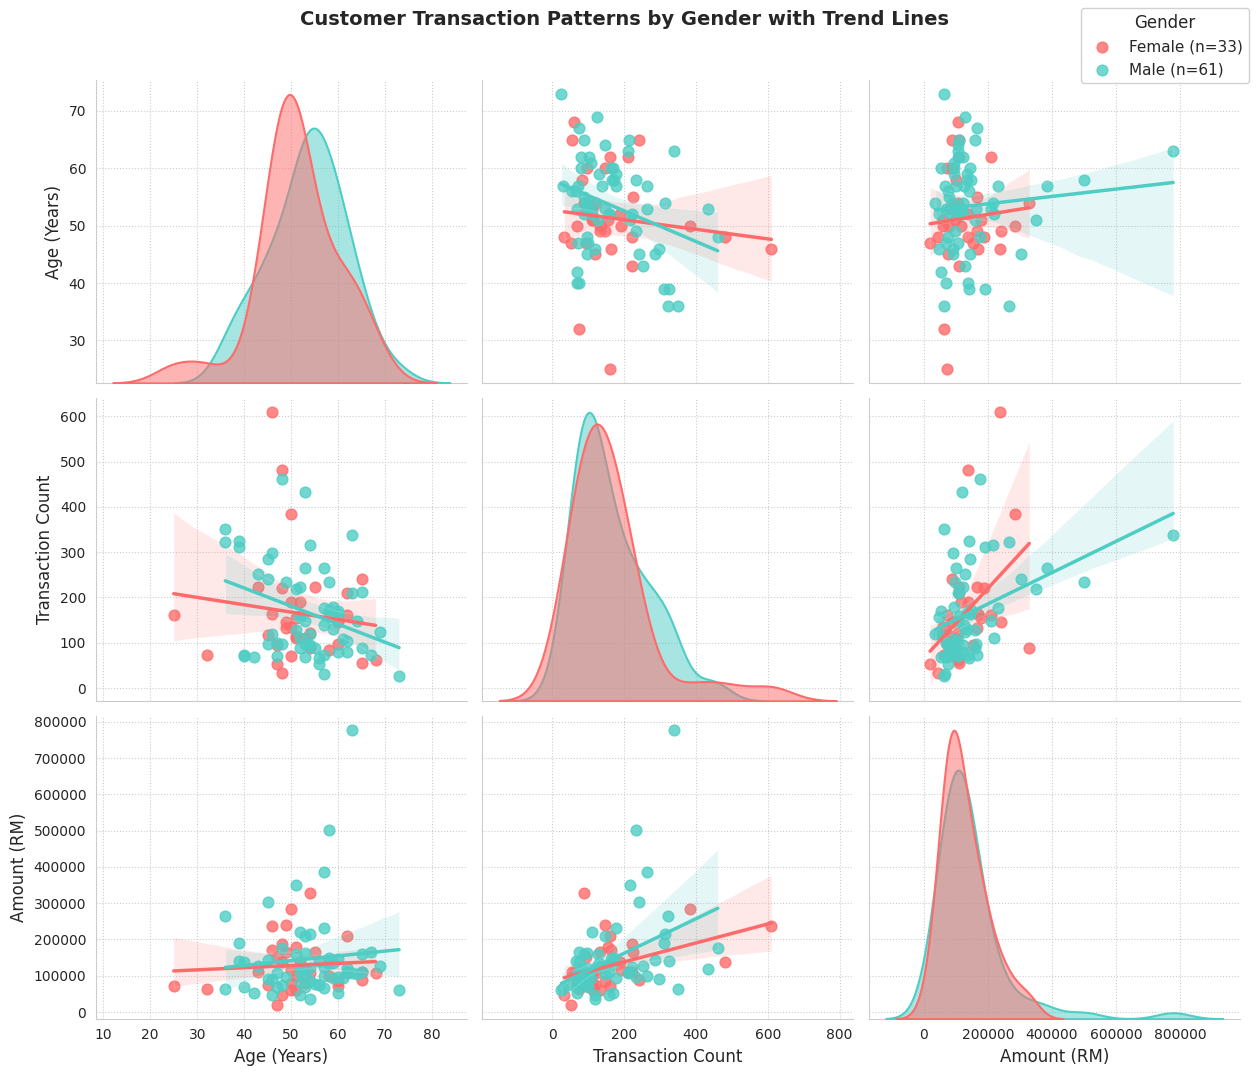

In [321]:
# @title
sns.set_style("whitegrid", {'grid.linestyle': ':', 'axes.edgecolor': '0.8'})
palette = {"FEMALE": "#FF6B6B", "MALE": "#4ECDC4"}

# Create pairplot with regression lines
g = sns.pairplot(
    data=trn_cus,
    hue='gndr',
    palette=palette,
    kind='reg',
    plot_kws={
        'scatter_kws': {'s': 60},  # Scatter point size
        'line_kws': {'linewidth': 2.5}  # Regression line thickness
    },
    diag_kws={
        'fill': True,
        'alpha': 0.5,
        'linewidth': 1.5,
        'common_norm': False
    },
    height=3.5,
    aspect=1.1
)

# Add title and adjust layout
plt.suptitle('Customer Transaction Patterns by Gender with Trend Lines',
             y=1.02, fontsize=14, fontweight='bold')

# Customize axis labels
for ax in g.axes.flatten():
    if ax:
        # X-axis labels
        if 'age' in ax.get_xlabel():
            ax.set_xlabel('Age (Years)', fontsize=12)
        elif 'count' in ax.get_xlabel():
            ax.set_xlabel('Transaction Count', fontsize=12)
        elif 'total_amount' in ax.get_xlabel():
            ax.set_xlabel('Amount (RM)', fontsize=12)

        # Y-axis labels
        if 'age' in ax.get_ylabel():
            ax.set_ylabel('Age (Years)', fontsize=12)
        elif 'count' in ax.get_ylabel():
            ax.set_ylabel('Transaction Count', fontsize=12)
        elif 'total_amount' in ax.get_ylabel():
            ax.set_ylabel('Amount (RM)', fontsize=12)

        # Customize ticks
        ax.tick_params(axis='both', which='major', labelsize=10)

# Improve legend
handles = g._legend_data.values()
labels = [f"Female (n={sum(trn_cus['gndr']=='FEMALE')})",
          f"Male (n={sum(trn_cus['gndr']=='MALE')})"]
g._legend.remove()
g.fig.legend(
    handles=handles,
    labels=labels,
    title='Gender',
    loc='upper right',
    frameon=True,
    framealpha=0.9,
    fontsize=11,
    title_fontsize=12
)

plt.tight_layout()
plt.show()

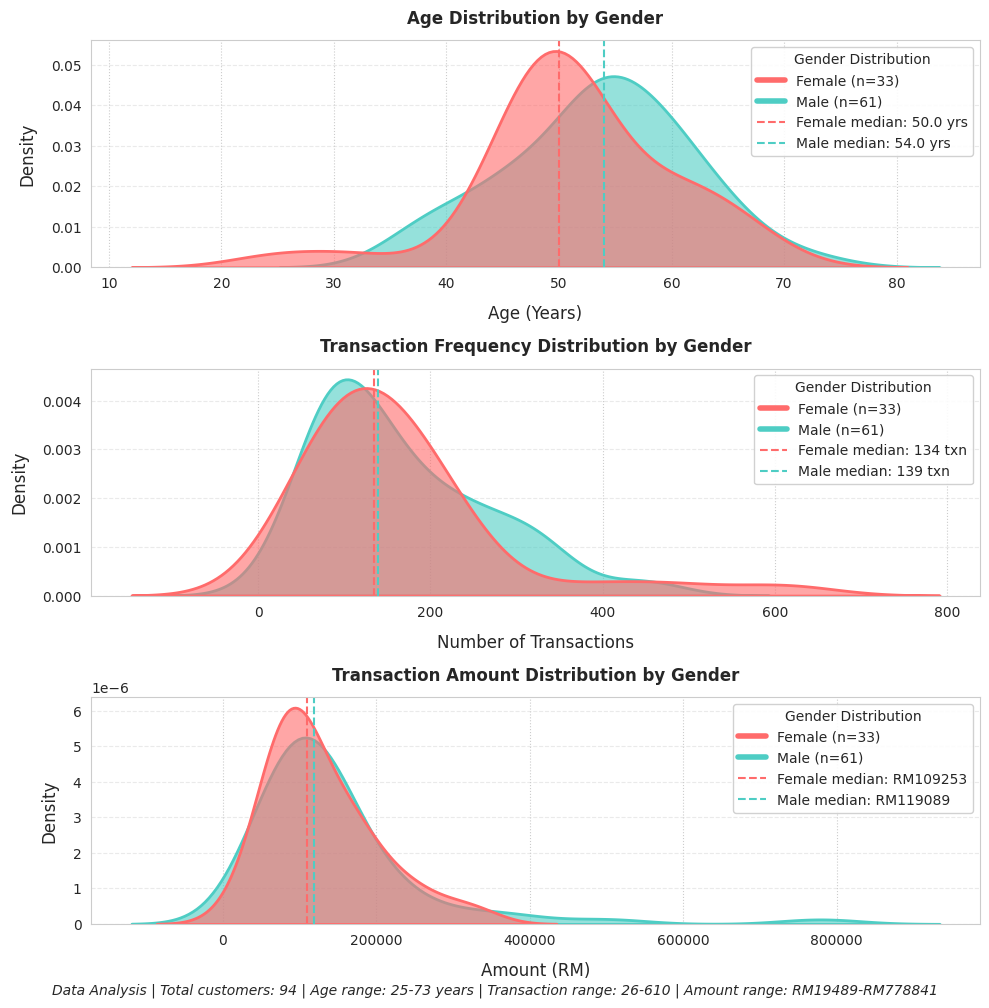

In [322]:
# @title
# Set up the figure and subplots
plt.figure(figsize=(10, 10), facecolor='white')

# Custom palette
palette = {"FEMALE": "#FF6B6B", "MALE": "#4ECDC4"}

# --------------------------------------------------------------------------
# Plot 1: Age Distribution
plt.subplot(3, 1, 1)
ax1 = sns.kdeplot(
    data=trn_cus,
    x='age',
    hue='gndr',
    palette=palette,
    fill=True,
    alpha=0.6,
    linewidth=2,
    common_norm=False
)

# Calculate medians and counts
medians = trn_cus.groupby('gndr')['age'].median()
counts = trn_cus['gndr'].value_counts()

# Add median lines
for gender, color in palette.items():
    plt.axvline(
        medians[gender],
        color=color,
        linestyle='--',
        linewidth=1.5
    )

# Custom legend
legend_elements = [
    Line2D([0], [0], color=palette['FEMALE'], lw=4, label=f"Female (n={counts.get('FEMALE', 0)})"),
    Line2D([0], [0], color=palette['MALE'], lw=4, label=f"Male (n={counts.get('MALE', 0)})"),
    Line2D([0], [0], color=palette['FEMALE'], linestyle='--', lw=1.5,
           label=f"Female median: {medians['FEMALE']:.1f} yrs"),
    Line2D([0], [0], color=palette['MALE'], linestyle='--', lw=1.5,
           label=f"Male median: {medians['MALE']:.1f} yrs")
]

plt.legend(handles=legend_elements, title='Gender Distribution', framealpha=0.9)
plt.title('Age Distribution by Gender', fontsize=12, pad=12, fontweight='bold')
plt.xlabel('Age (Years)', fontsize=12, labelpad=10)
plt.ylabel('Density', fontsize=12, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# --------------------------------------------------------------------------
# Plot 2: Transaction Frequency Distribution
plt.subplot(3, 1, 2)
ax2 = sns.kdeplot(
    data=trn_cus,
    x='count',
    hue='gndr',
    palette=palette,
    fill=True,
    alpha=0.6,
    linewidth=2,
    common_norm=False
)

# Calculate medians
medians = trn_cus.groupby('gndr')['count'].median()

# Add median lines
for gender, color in palette.items():
    plt.axvline(
        medians[gender],
        color=color,
        linestyle='--',
        linewidth=1.5
    )

# Custom legend
legend_elements = [
    Line2D([0], [0], color=palette['FEMALE'], lw=4, label=f"Female (n={counts.get('FEMALE', 0)})"),
    Line2D([0], [0], color=palette['MALE'], lw=4, label=f"Male (n={counts.get('MALE', 0)})"),
    Line2D([0], [0], color=palette['FEMALE'], linestyle='--', lw=1.5,
           label=f"Female median: {medians['FEMALE']:.0f} txn"),
    Line2D([0], [0], color=palette['MALE'], linestyle='--', lw=1.5,
           label=f"Male median: {medians['MALE']:.0f} txn")
]

plt.legend(handles=legend_elements, title='Gender Distribution', framealpha=0.9)
plt.title('Transaction Frequency Distribution by Gender', fontsize=12, pad=12, fontweight='bold')
plt.xlabel('Number of Transactions', fontsize=12, labelpad=10)
plt.ylabel('Density', fontsize=12, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# --------------------------------------------------------------------------
# Plot 3: Transaction Amount Distribution
plt.subplot(3, 1, 3)
ax3 = sns.kdeplot(
    data=trn_cus,
    x='total_amount',
    hue='gndr',
    palette=palette,
    fill=True,
    alpha=0.6,
    linewidth=2,
    common_norm=False
)

# Calculate medians
medians = trn_cus.groupby('gndr')['total_amount'].median()

# Add median lines
for gender, color in palette.items():
    plt.axvline(
        medians[gender],
        color=color,
        linestyle='--',
        linewidth=1.5
    )

# Custom legend
legend_elements = [
    Line2D([0], [0], color=palette['FEMALE'], lw=4, label=f"Female (n={counts.get('FEMALE', 0)})"),
    Line2D([0], [0], color=palette['MALE'], lw=4, label=f"Male (n={counts.get('MALE', 0)})"),
    Line2D([0], [0], color=palette['FEMALE'], linestyle='--', lw=1.5,
           label=f"Female median: RM{medians['FEMALE']:.0f}"),
    Line2D([0], [0], color=palette['MALE'], linestyle='--', lw=1.5,
           label=f"Male median: RM{medians['MALE']:.0f}")
]

plt.legend(handles=legend_elements, title='Gender Distribution', framealpha=0.9)
plt.title('Transaction Amount Distribution by Gender', fontsize=12, pad=12, fontweight='bold')
plt.xlabel('Amount (RM)', fontsize=12, labelpad=10)
plt.ylabel('Density', fontsize=12, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# --------------------------------------------------------------------------
# Add footer
plt.figtext(0.5, 0,
           f"Data Analysis | Total customers: {len(trn_cus)} | Age range: {trn_cus['age'].min():.0f}-{trn_cus['age'].max():.0f} years | Transaction range: {trn_cus['count'].min():.0f}-{trn_cus['count'].max():.0f} | Amount range: RM{trn_cus['total_amount'].min():.0f}-RM{trn_cus['total_amount'].max():.0f}",
           ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

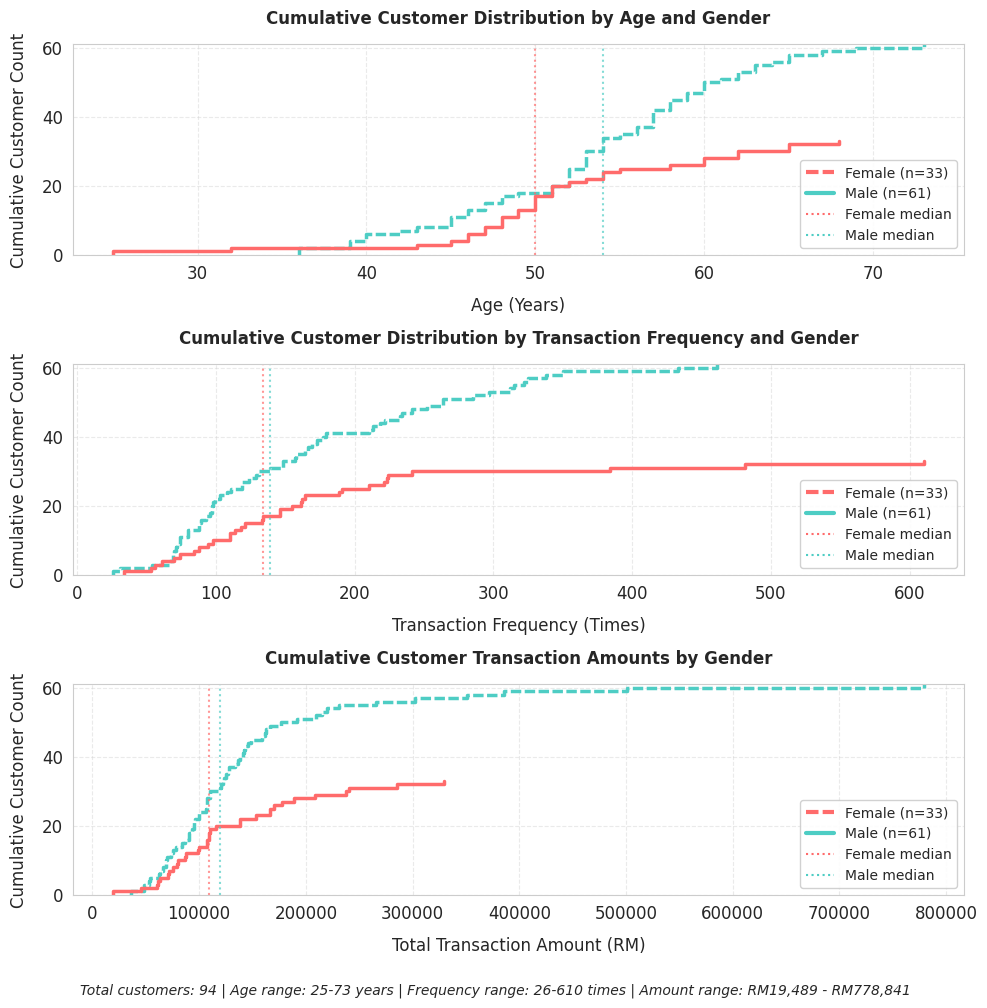

In [323]:
# @title
fig, axes = plt.subplots(3, 1, figsize=(10, 10), facecolor='white', sharey=True)

# --- Helper function to apply common ECDF styling and elements ---
def plot_ecdf_subplot(ax, x_col, title, x_label, median_label_suffix=''):
    """Plots an ECDF on a given axes, with common styling."""
    sns.ecdfplot(
        data=trn_cus,
        x=x_col,
        hue="gndr",
        stat="count",
        palette=palette,
        linewidth=2.5,
        ax=ax # Assign to the specific subplot axis
    )

    # Apply specific line styles (dashed for Female, solid for Male)
    lines = ax.lines
    for i, line in enumerate(lines):
        if i % 2 == 0:
            line.set_linestyle((0, (3, 1))) # Dashed line
        else:
            line.set_linestyle('-') # Solid line

    # Add vertical lines for medians
    medians = trn_cus.groupby('gndr')[x_col].median()
    for gender, color in palette.items():
        # Format median label based on the variable type
        if 'amount' in x_col:
            median_val_str = f"RM{medians[gender]:,.1f}"
        else:
            median_val_str = f"{medians[gender]:.1f}"

        ax.axvline(
            medians[gender],
            color=color,
            linestyle=':', # Dotted line for median
            linewidth=1.5,
            alpha=0.7,
            label=f'{gender} median: {median_val_str} {median_label_suffix}'
        )

    # Set title and labels for the subplot
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel(x_label, fontsize=12, labelpad=10)
    ax.set_ylabel('Cumulative Customer Count', fontsize=12, labelpad=10) # Consistent Y-label
    ax.grid(True, linestyle='--', alpha=0.4) # Grid lines
    ax.set_axisbelow(True) # Grid behind lines
    ax.tick_params(labelsize=12) # Tick label font size

    # Create and place the custom legend for the subplot
    counts_gndr = trn_cus['gndr'].value_counts()
    legend_elements = [
        Line2D([0], [0], color=palette['FEMALE'], lw=3, linestyle=(0, (3, 1)),
               label=f"Female (n={counts_gndr.get('FEMALE', 0)})"),
        Line2D([0], [0], color=palette['MALE'], lw=3, linestyle='-',
               label=f"Male (n={counts_gndr.get('MALE', 0)})"),
        Line2D([0], [0], color=palette['FEMALE'], linestyle=':', lw=1.5,
               label=f'Female median'),
        Line2D([0], [0], color=palette['MALE'], linestyle=':', lw=1.5,
               label=f'Male median')
    ]
    ax.legend(handles=legend_elements, fontsize=10, framealpha=0.9,
              loc='lower right', bbox_to_anchor=(1, 0))


# Plot 1: Cumulative Customer Distribution by Age
plot_ecdf_subplot(axes[0], "age",
                  'Cumulative Customer Distribution by Age and Gender',
                  'Age (Years)', 'yrs')

# Plot 2: Cumulative Customer Distribution by Transaction Frequency
plot_ecdf_subplot(axes[1], "count",
                  'Cumulative Customer Distribution by Transaction Frequency and Gender',
                  'Transaction Frequency (Times)', 'times')

# Plot 3: Cumulative Customer Transaction Amounts
plot_ecdf_subplot(axes[2], "total_amount",
                  'Cumulative Customer Transaction Amounts by Gender',
                  'Total Transaction Amount (RM)', '') # No specific unit suffix for amount median

# --- Overall Figure Footnote ---
total_customers = len(trn_cus)
age_range_str = f"{trn_cus['age'].min():.0f}-{trn_cus['age'].max():.0f} years"
freq_range_str = f"{trn_cus['count'].min():.0f}-{trn_cus['count'].max():.0f} times"
amount_range_str = f"RM{trn_cus['total_amount'].min():,.0f} - RM{trn_cus['total_amount'].max():,.0f}"

plt.figtext(0.5, 0,
            f"Total customers: {total_customers:,} | Age range: {age_range_str} | "
            f"Frequency range: {freq_range_str} | Amount range: {amount_range_str}",
            ha='center', fontsize=10, style='italic')

# --- Final Layout Adjustment ---
plt.tight_layout(rect=[0, 0.025, 1, 1])
plt.show()

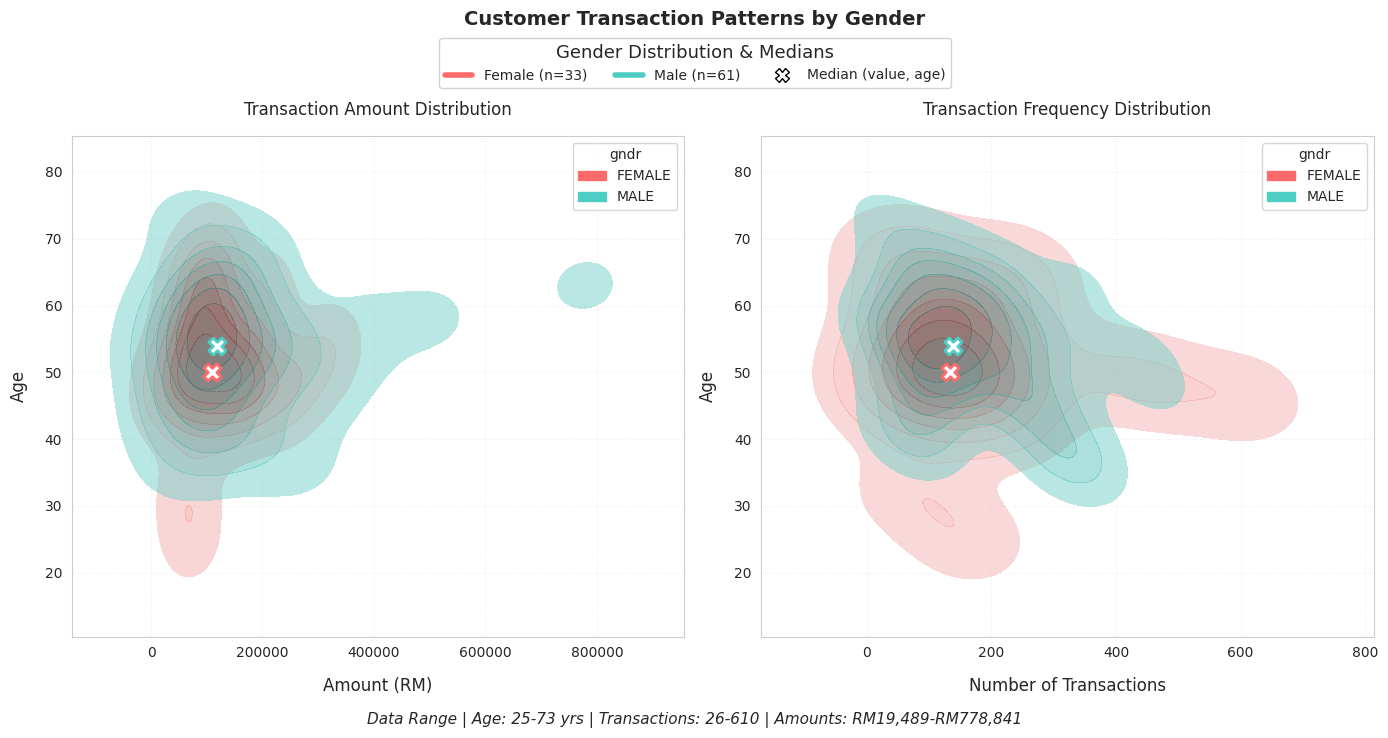

In [324]:
# @title
# Set up the figure with a professional color scheme
fig = plt.figure(figsize=(14, 7), facecolor='white')
plt.suptitle('Customer Transaction Patterns by Gender', fontsize=14, fontweight='bold', y=1.03) # Increased suptitle font size

# Define the custom palette with better contrast
palette = {"FEMALE": "#FF6B6B", "MALE": "#4ECDC4"} # Reddish for Female, Teal for Male

# =============================================
# LEFT PLOT: Transaction Amount Distribution (KDE)
# =============================================
ax1 = fig.add_subplot(1, 2, 1) # Explicitly add subplot to the figure

# Create KDE plot with enhanced styling
sns.kdeplot(
    data=trn_cus,
    x='total_amount',
    y='age',
    hue='gndr',
    palette=palette,
    fill=True,
    alpha=0.5,
    thresh=0.05, # Consistent threshold
    levels=8,    # Consistent levels
    common_norm=False,
    ax=ax1 # Plot on ax1
)

# Calculate medians and counts (done once for both plots)
medians = trn_cus.groupby('gndr').agg({'total_amount':'median', 'age':'median', 'count':'median'})
counts = trn_cus['gndr'].value_counts()

# Add median points with enhanced visibility
for gender, color in palette.items():
    ax1.scatter( # Use ax1.scatter
        medians.loc[gender, 'total_amount'],
        medians.loc[gender, 'age'],
        color='white',
        s=150,
        edgecolor=color,
        linewidth=2.0,
        marker='X',
        label=f'{gender} Median',
        zorder=5
    )

# Formatting for ax1
ax1.set_title('Transaction Amount Distribution', fontsize=12, pad=15)
ax1.set_xlabel('Amount (RM)', fontsize=12, labelpad=12)
ax1.set_ylabel('Age', fontsize=12, labelpad=12)
ax1.grid(True, linestyle=':', alpha=0.3)

# =============================================
# RIGHT PLOT: Transaction Frequency Distribution (KDE)
# =============================================
ax2 = fig.add_subplot(1, 2, 2)

# Create KDE plot
sns.kdeplot(
    data=trn_cus,
    x='count',
    y='age',
    hue='gndr',
    palette=palette,
    fill=True,
    alpha=0.5,
    thresh=0.05,
    levels=8,
    common_norm=False,
    ax=ax2 # Plot on ax2
)

# Add median points with enhanced visibility
for gender, color in palette.items():
    ax2.scatter( # Use ax2.scatter
        medians.loc[gender, 'count'],
        medians.loc[gender, 'age'],
        color='white',
        s=150,
        edgecolor=color,
        linewidth=2.0,
        marker='X',
        label=f'{gender} Median',
        zorder=5
    )

# Formatting for ax2
ax2.set_title('Transaction Frequency Distribution', fontsize=12, pad=15)
ax2.set_xlabel('Number of Transactions', fontsize=12, labelpad=12)
ax2.set_ylabel('Age', fontsize=12, labelpad=12)
ax2.grid(True, linestyle=':', alpha=0.3)

# =============================================
# SHARED LEGEND (Figure-level)
# =============================================
n_female = counts.get('FEMALE', 0)
n_male = counts.get('MALE', 0)

legend_elements = [
    Line2D([0], [0], color=palette['FEMALE'], lw=4, label=f"Female (n={n_female})"),
    Line2D([0], [0], color=palette['MALE'], lw=4, label=f"Male (n={n_male})"),
    Line2D([0], [0], marker='X', color='w', markeredgecolor='black',
           markersize=10, lw=0, label='Median (value, age)')
]

fig.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.0), # Adjust bbox_to_anchor to place it above suptitle
    ncol=3,
    fontsize=10,
    framealpha=0.9,
    title='Gender Distribution & Medians',
    title_fontsize=13
)

# =============================================
# DATA FOOTNOTE (Figure-level)
# =============================================
plt.figtext(
    0.5, 0.01, # Positioned centrally at the bottom of the entire figure
    f"Data Range | Age: {trn_cus['age'].min():.0f}-{trn_cus['age'].max():.0f} yrs | "
    f"Transactions: {trn_cus['count'].min():.0f}-{trn_cus['count'].max():.0f} | "
    f"Amounts: RM{trn_cus['total_amount'].min():,.0f}-RM{trn_cus['total_amount'].max():,.0f}",
    ha='center', fontsize=11, style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Adjusted top margin to make space for suptitle and legend

plt.show()

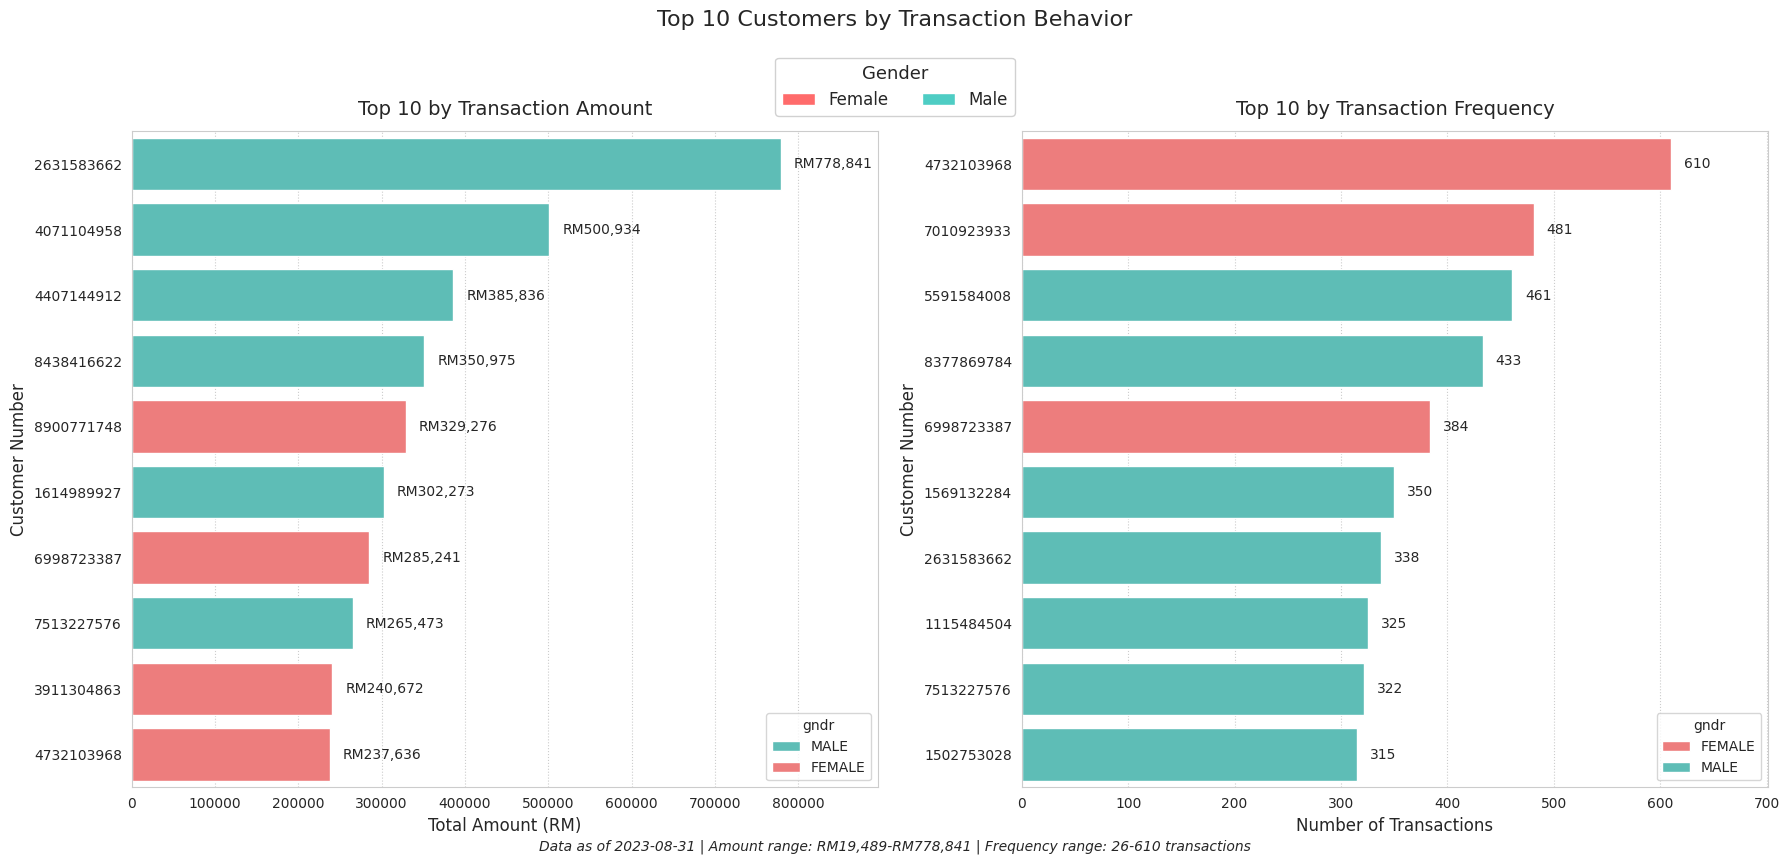

In [325]:
# @title
plt.figure(figsize=(18, 8))
plt.suptitle('Top 10 Customers by Transaction Behavior', fontsize=16, y=1.05)

# =============================================
# 1. Top 10 Customers by Transaction Amount
# =============================================
plt.subplot(1, 2, 1)

# Get top 10 customers by amount
top_amount = trn_cus.sort_values('total_amount', ascending=False).head(10)
bar1 = sns.barplot(
    data=top_amount,
    x='total_amount',
    y='cus_no',
    hue='gndr',
    palette=palette,
    orient='h',
    dodge=False,
    edgecolor='white',
    linewidth=1
)

# Add value labels
for i, (_, row) in enumerate(top_amount.iterrows()):
    bar1.text(
        row['total_amount'] + max(top_amount['total_amount'])*0.02,
        i,
        f"RM{row['total_amount']:,.0f}",
        va='center',
        fontsize=10
    )

# Formatting
plt.title('Top 10 by Transaction Amount', fontsize=14, pad=12)
plt.xlabel('Total Amount (RM)', fontsize=12)
plt.ylabel('Customer Number', fontsize=12)
plt.xlim(0, max(top_amount['total_amount'])*1.15)

# =============================================
# 2. Top 10 Customers by Transaction Frequency
# =============================================
plt.subplot(1, 2, 2)

# Get top 10 customers by frequency
top_freq = trn_cus.sort_values('count', ascending=False).head(10)
bar2 = sns.barplot(
    data=top_freq,
    x='count',
    y='cus_no',
    hue='gndr',
    palette=palette,
    orient='h',
    dodge=False,
    edgecolor='white',
    linewidth=1
)

# Add value labels
for i, (_, row) in enumerate(top_freq.iterrows()):
    bar2.text(
        row['count'] + max(top_freq['count'])*0.02,
        i,
        f"{row['count']}",
        va='center',
        fontsize=10
    )

# Formatting
plt.title('Top 10 by Transaction Frequency', fontsize=14, pad=12)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Customer Number', fontsize=12)
plt.xlim(0, max(top_freq['count'])*1.15)

# =============================================
# Shared Legend
# =============================================
handles = [
    plt.Rectangle((0,0),1,1, fc=palette['FEMALE'], edgecolor='white'),
    plt.Rectangle((0,0),1,1, fc=palette['MALE'], edgecolor='white')
]
labels = ['Female', 'Male']

plt.figlegend(
    handles=handles,
    labels=labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=2,
    frameon=True,
    framealpha=0.9,
    fontsize=12,
    title='Gender',
    title_fontsize=13
)

# =============================================
# Data Source Footnote
# =============================================
plt.figtext(
    0.5, 0,
    f"Data as of {df['trn_dt'].max().strftime('%Y-%m-%d')} | "
    f"Amount range: RM{trn_cus['total_amount'].min():,.0f}-RM{trn_cus['total_amount'].max():,.0f} | "
    f"Frequency range: {trn_cus['count'].min()}-{trn_cus['count'].max()} transactions",
    ha='center',
    fontsize=10,
    style='italic'
)

plt.tight_layout()
plt.show()

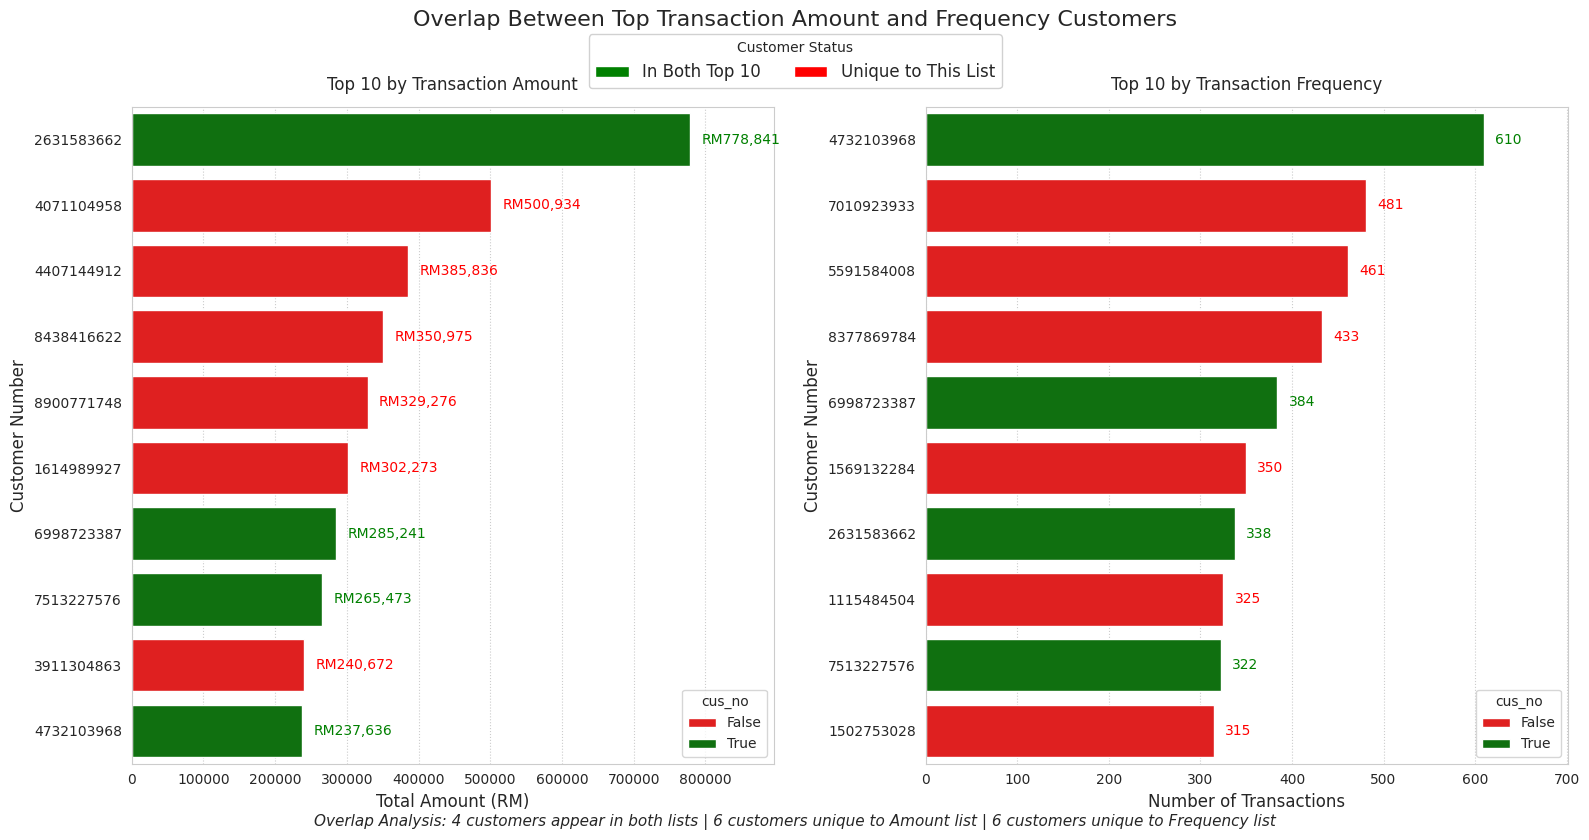


Customers appearing in both top 10 lists:


,cus_no,gndr,age,count,total_amount
16,2631583662,MALE,63.0,338,778841.06
56,6998723387,FEMALE,50.0,384,285240.60
66,7513227576,MALE,36.0,322,265472.51
40,4732103968,FEMALE,46.0,610,237635.74


In [326]:
# @title
# Get the top 10 customers for amount and frequency
top_amount = trn_cus.sort_values('total_amount', ascending=False).head(10)
top_freq = trn_cus.sort_values('count', ascending=False).head(10)

# Find the overlapping customers
common_customers = set(top_amount['cus_no']).intersection(set(top_freq['cus_no']))
is_common_amount = top_amount['cus_no'].isin(common_customers)
is_common_freq = top_freq['cus_no'].isin(common_customers)

# Create the visualization
plt.figure(figsize=(16, 8))
plt.suptitle('Overlap Between Top Transaction Amount and Frequency Customers', fontsize=16, y=1.02)

# --------------------------------------------------
# Plot 1: Top Amount Customers with Overlap Highlight
# --------------------------------------------------
plt.subplot(1, 2, 1)
bar1 = sns.barplot(
    data=top_amount,
    x='total_amount',
    y='cus_no',
    hue=is_common_amount,
    palette={True: 'green', False: 'red'},
    orient='h',
    dodge=False,
    edgecolor='white',
    linewidth=1
)

# Add value labels
for i, (_, row) in enumerate(top_amount.iterrows()):
    color = 'green' if row['cus_no'] in common_customers else 'red'
    bar1.text(
        row['total_amount'] + max(top_amount['total_amount'])*0.02,
        i,
        f"RM{row['total_amount']:,.0f}",
        va='center',
        fontsize=10,
        color=color
    )

plt.title('Top 10 by Transaction Amount', fontsize=12, pad=12)
plt.xlabel('Total Amount (RM)', fontsize=12)
plt.ylabel('Customer Number', fontsize=12)
plt.xlim(0, max(top_amount['total_amount'])*1.15)

# --------------------------------------------------
# Plot 2: Top Frequency Customers with Overlap Highlight
# --------------------------------------------------
plt.subplot(1, 2, 2)
bar2 = sns.barplot(
    data=top_freq,
    x='count',
    y='cus_no',
    hue=is_common_freq,
    palette={True: 'green', False: 'red'},
    orient='h',
    dodge=False,
    edgecolor='white',
    linewidth=1
)

# Add value labels
for i, (_, row) in enumerate(top_freq.iterrows()):
    color = 'green' if row['cus_no'] in common_customers else 'red'
    bar2.text(
        row['count'] + max(top_freq['count'])*0.02,
        i,
        f"{row['count']}",
        va='center',
        fontsize=10,
        color=color
    )

plt.title('Top 10 by Transaction Frequency', fontsize=12, pad=12)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Customer Number', fontsize=12)
plt.xlim(0, max(top_freq['count'])*1.15)

# --------------------------------------------------
# Custom Legend
# --------------------------------------------------
legend_elements = [
    plt.Rectangle((0,0),1,1, fc='green', edgecolor='white', label='In Both Top 10'),
    plt.Rectangle((0,0),1,1, fc='red', edgecolor='white', label='Unique to This List')
]

plt.figlegend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=2,
    frameon=True,
    framealpha=0.9,
    fontsize=12,
    title='Customer Status',
    title_fontsize=10
)

# --------------------------------------------------
# Summary Statistics
# --------------------------------------------------
overlap_count = len(common_customers)
unique_amount = len(top_amount) - overlap_count
unique_freq = len(top_freq) - overlap_count

plt.figtext(
    0.5, 0,
    f"Overlap Analysis: {overlap_count} customers appear in both lists | "
    f"{unique_amount} customers unique to Amount list | "
    f"{unique_freq} customers unique to Frequency list",
    ha='center',
    fontsize=11,
    style='italic'
)

plt.tight_layout()
plt.show()

# Print the overlapping customers
if len(common_customers) > 0:
    print("\nCustomers appearing in both top 10 lists:")
    overlap_df = top_amount[top_amount['cus_no'].isin(common_customers)]
    display(overlap_df[['cus_no', 'gndr', 'age', 'count', 'total_amount']])
else:
    print("\nNo customers appear in both top 10 lists")

In [327]:
# @title
# Oldest customer(s)
oldest_age = trn_cus['age'].max()
oldest_customers = trn_cus[trn_cus['age'] == oldest_age]

print(f"Oldest customer(s) (age {oldest_age} years):")
for index, row in oldest_customers.iterrows():
    print(f"  Customer Number: {row['cus_no']}, Age: {row['age']} years")

# Youngest customer(s)
youngest_age = trn_cus['age'].min()
youngest_customers = trn_cus[trn_cus['age'] == youngest_age]

print(f"\nYoungest customer(s) (age {youngest_age} years):")
for index, row in youngest_customers.iterrows():
    print(f"  Customer Number: {row['cus_no']}, Age: {row['age']} years")

Oldest customer(s) (age 73.0 years):
  Customer Number: 2435083796, Age: 73.0 years

Youngest customer(s) (age 25.0 years):
  Customer Number: 2734670470, Age: 25.0 years


In [328]:
# @title
# Largest transaction made customer(s)
biggest_amt = trn_cus['total_amount'].max()
biggest_customer = trn_cus[trn_cus['total_amount'] == biggest_amt]

print(f"Largest transaction made is RM {biggest_amt}:")
for index, row in biggest_customer.iterrows():
    print(f"  Customer Number: {row['cus_no']}, Age: {row['age']} years")

# Smallest transaction made customer(s)
smallest_amt = trn_cus['total_amount'].min()
smallest_customer = trn_cus[trn_cus['total_amount'] == biggest_amt]

print(f"\nSmallest transaction made is RM {smallest_amt}:")
for index, row in smallest_customer.iterrows():
    print(f"  Customer Number: {row['cus_no']}, Age: {row['age']} years")

# Most frequent transaction made customer(s)
most_freq = trn_cus['count'].max()
most_customer = trn_cus[trn_cus['count'] == most_freq]

print(f"\nMost transactions made is {most_freq} times:")
for index, row in most_customer.iterrows():
    print(f"  Customer Number: {row['cus_no']}, Age: {row['age']} years")

# Least frequent transaction made customer(s)
least_freq = trn_cus['count'].min()
least_customer = trn_cus[trn_cus['count'] == least_freq]

print(f"\nLeast transactions made is {least_freq} times:")
for index, row in least_customer.iterrows():
    print(f"  Customer Number: {row['cus_no']}, Age: {row['age']} years")

Largest transaction made is RM 778841.06:
  Customer Number: 2631583662, Age: 63.0 years

Smallest transaction made is RM 19489.0:
  Customer Number: 2631583662, Age: 63.0 years

Most transactions made is 610 times:
  Customer Number: 4732103968, Age: 46.0 years

Least transactions made is 26 times:
  Customer Number: 2435083796, Age: 73.0 years


## Transaction Volume

In [329]:
# @title
trn_volume = df.groupby('trn_dt').size().reset_index(name='count')
trn_volume['trn_dt'] = pd.to_datetime(trn_volume['trn_dt'])
trn_volume['month'] = trn_volume['trn_dt'].dt.month
trn_volume['week'] = trn_volume['trn_dt'].dt.isocalendar().week
trn_volume['day'] = trn_volume['trn_dt'].dt.day
trn_volume['day_name'] = trn_volume['trn_dt'].dt.day_name()
display(trn_volume.head())

,trn_dt,count,month,week,day,day_name
0,2023-06-01,221,6,22,1,Thursday
1,2023-06-02,182,6,22,2,Friday
2,2023-06-03,165,6,22,3,Saturday
3,2023-06-04,129,6,22,4,Sunday
4,2023-06-05,126,6,23,5,Monday


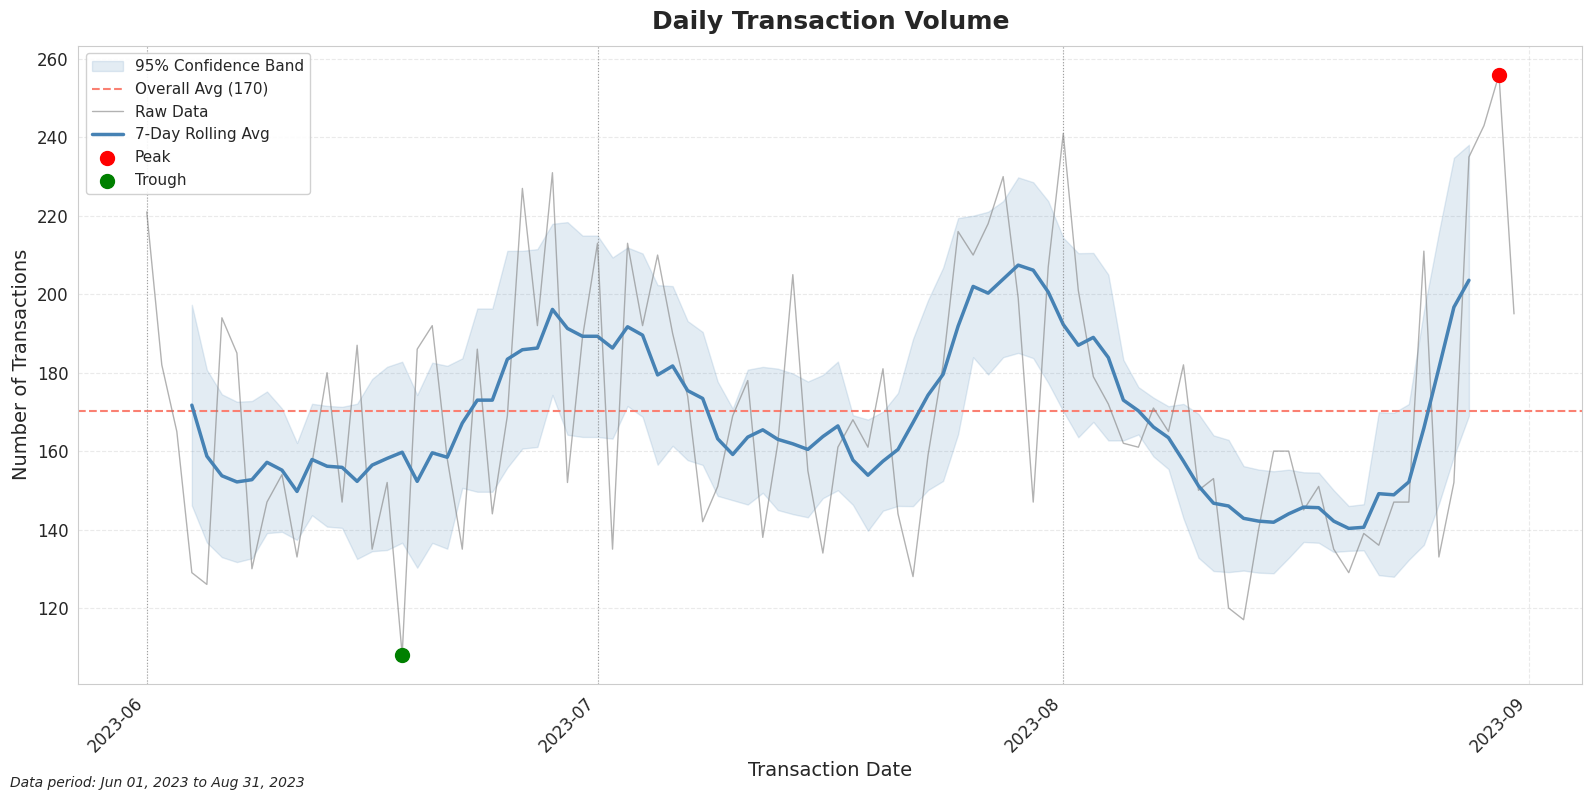

In [330]:
# @title
plt.figure(figsize=(16, 8), facecolor='white')

# --- Smoothing with Rolling Average & Confidence Band ---
window = 7
trn_volume['smoothed'] = trn_volume['count'].rolling(window, center=True).mean()
trn_volume['std'] = trn_volume['count'].rolling(window, center=True).std()
ci = 1.96 * trn_volume['std'] / (window**0.5)  # 95% CI

# Plot confidence band
plt.fill_between(trn_volume['trn_dt'],
                 trn_volume['smoothed'] - ci,
                 trn_volume['smoothed'] + ci,
                 color='steelblue', alpha=0.15, label='95% Confidence Band')

avg_count = trn_volume['count'].mean()
plt.axhline(y=avg_count, color='salmon', linestyle='--', linewidth=1.5,
            label=f'Overall Avg ({avg_count:,.0f})')

# --- Plot Raw vs. Smoothed ---
sns.lineplot(data=trn_volume, x='trn_dt', y='count',
             color='gray', linewidth=1, alpha=0.6, label='Raw Data')
sns.lineplot(data=trn_volume, x='trn_dt', y='smoothed',
             color='steelblue', linewidth=2.5, label=f'{window}-Day Rolling Avg')

# --- Highlight Peaks & Troughs ---
max_idx = trn_volume['count'].idxmax()
min_idx = trn_volume['count'].idxmin()
plt.scatter(trn_volume.loc[max_idx, 'trn_dt'], trn_volume.loc[max_idx, 'count'],
            color='red', s=100, zorder=5, label='Peak')
plt.scatter(trn_volume.loc[min_idx, 'trn_dt'], trn_volume.loc[min_idx, 'count'],
            color='green', s=100, zorder=5, label='Trough')

# --- Add Vertical Lines for Month Starts ---
ax = plt.gca()
for date in pd.date_range(trn_volume['trn_dt'].min(), trn_volume['trn_dt'].max(), freq='MS'):
    ax.axvline(date, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
ax.xaxis.set_major_locator(mdates.MonthLocator())  # Ensure ticks align with lines

# --- Annotate Significant Events (Customize Dates) ---
events = {
    '2023-01-15': 'Promotion Campaign',  # Replace with real events
    '2023-03-10': 'System Outage'
}
for date_str, label in events.items():
    date = pd.to_datetime(date_str)
    if date in trn_volume['trn_dt'].values:
        y_val = trn_volume[trn_volume['trn_dt'] == date]['count'].values[0]
        plt.annotate(label, xy=(date, y_val), xytext=(10, 20),
                    textcoords='offset points', arrowprops=dict(arrowstyle='->'),
                    bbox=dict(boxstyle='round',pad=0.5, fc='yellow', alpha=0.8))

# --- Formatting ---
plt.title('Daily Transaction Volume',
          fontsize=18, fontweight='bold', pad=12)
plt.xlabel('Transaction Date', fontsize=14)
plt.ylabel('Number of Transactions', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=11, framealpha=0.9, loc='upper left')

# Footer with data range
plt.figtext(0.1, 0.01,
            f"Data period: {trn_volume['trn_dt'].min().strftime('%b %d, %Y')} to {trn_volume['trn_dt'].max().strftime('%b %d, %Y')}",
            ha='center', fontsize=10, style='italic')
plt.tight_layout()
plt.show()

In [331]:
# @title
max_idx = trn_volume['count'].idxmax()
min_idx = trn_volume['count'].idxmin()

# Get the peak dates from trn_volume
peak_date = trn_volume.loc[max_idx, 'trn_dt']  # Highest peak date
trough_date = trn_volume.loc[min_idx, 'trn_dt']  # Lowest peak date

# Get the peak count from trn_volume
peak_ct = trn_volume.loc[max_idx, 'count']  # Highest peak count
trough_ct = trn_volume.loc[min_idx, 'count']  # Lowest peak count

# Convert 'trn_dt' to datetime objects in the original DataFrame
df['trn_dt'] = pd.to_datetime(df['trn_dt'])

# Extract all transactions on these dates from your full DataFrame
peak_trn = df[df['trn_dt'].dt.date == peak_date.date()]
trough_trn = df[df['trn_dt'].dt.date == trough_date.date()]

# Display the results
print(f"\nTransactions on peak date ({peak_date.date()}) with {peak_ct} transactions")
print(f"\nTransactions on trough date ({trough_date.date()}) with {trough_ct} transactions")


Transactions on peak date (2023-08-30) with 256 transactions

Transactions on trough date (2023-06-18) with 108 transactions


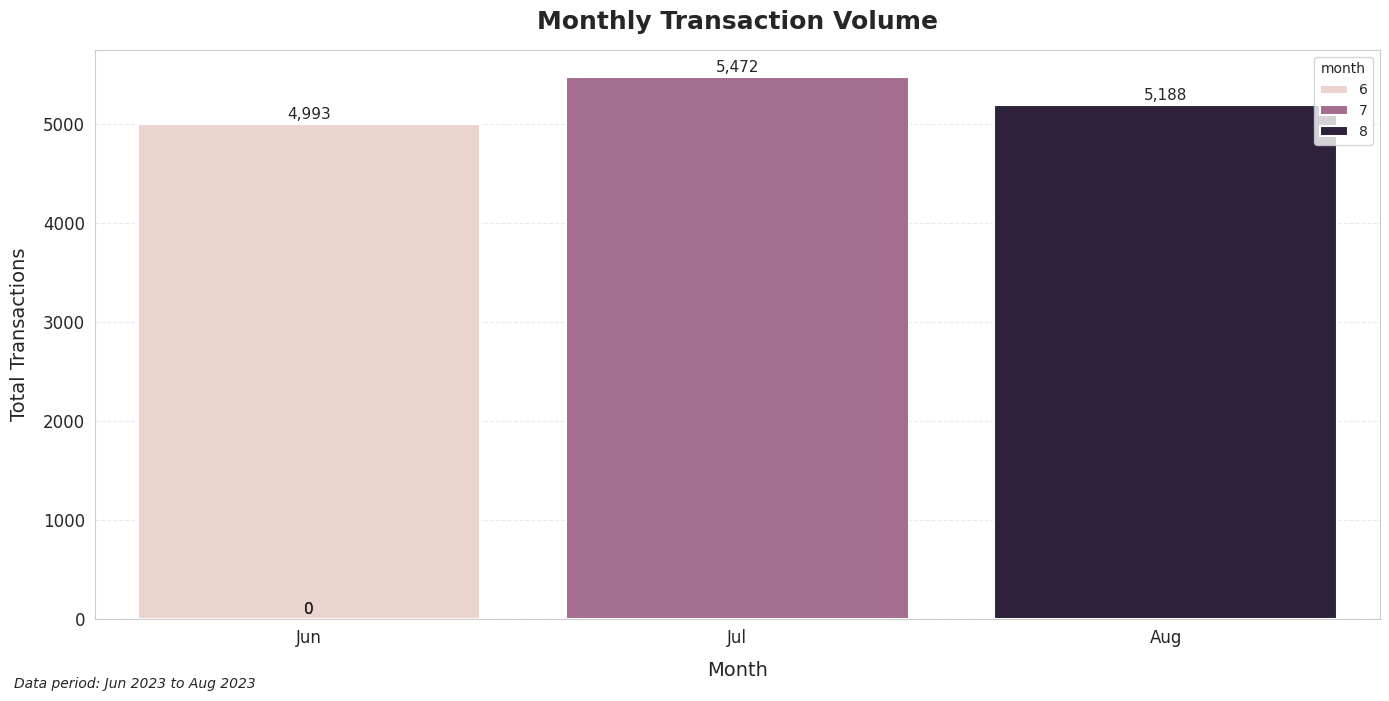

In [332]:
# @title
plt.figure(figsize=(14, 7), facecolor='white')

ax = sns.barplot(
    x='month',
    y='count',
    data=trn_volume.groupby('month')['count'].sum().reset_index(),
    hue='month',
    saturation=0.85,
    edgecolor='white',
    linewidth=1.5
)

plt.title('Monthly Transaction Volume',
          fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=14, labelpad=10)
plt.ylabel('Total Transactions', fontsize=14, labelpad=10)

plt.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.xticks(range(3), ['Jun', 'Jul', 'Aug'],
           fontsize=12)
plt.yticks(fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 7),
                textcoords='offset points',
                fontsize=11)

plt.figtext(0.1, 0.01,
           f"Data period: {trn_volume['trn_dt'].min().strftime('%b %Y')} to {trn_volume['trn_dt'].max().strftime('%b %Y')}",
           ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

<ipython-input-333-bb69c4bdd804>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


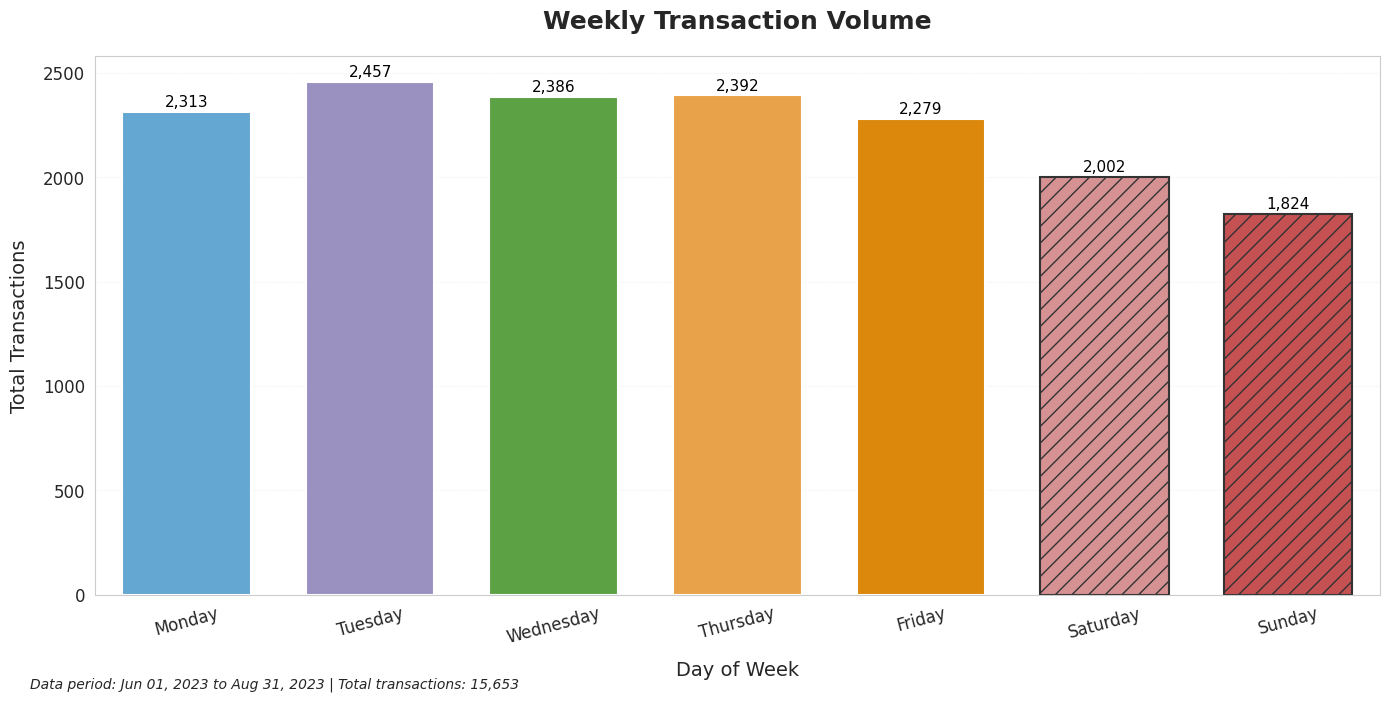

In [333]:
# @title
plt.figure(figsize=(14, 7), facecolor='white')

palette = ['#5DA8D8', '#998EC3', '#5BA640', '#F1A340',
           '#E68A00', '#DA8D8F', '#CB4B4C']

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
             'Friday', 'Saturday', 'Sunday']

ax = sns.barplot(
    x='day_name',
    y='count',
    data=trn_volume.groupby('day_name')['count'].sum().reset_index(),
    order=day_order,
    palette=palette,
    saturation=0.9,
    edgecolor='white',
    linewidth=1.5,
    width=0.7
)

plt.title('Weekly Transaction Volume',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Day of Week', fontsize=14, labelpad=10)
plt.ylabel('Total Transactions', fontsize=14, labelpad=10)

plt.grid(axis='y', linestyle=':', alpha=0.3)
ax.set_axisbelow(True)

plt.xticks(fontsize=12, rotation=15)
plt.yticks(fontsize=12)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom' if p.get_height() < max([p.get_height() for p in ax.patches])*0.1 else 'center',
        xytext=(0, 7),
        textcoords='offset points',
        fontsize=11,
        color='black' if p.get_height() > max([p.get_height() for p in ax.patches])*0.3 else 'gray'
    )

for i, day in enumerate(day_order):
    if day in ['Saturday', 'Sunday']:
        ax.patches[i].set_hatch('//')
        ax.patches[i].set_edgecolor('#333333')

plt.figtext(0.2, 0.01,
           f"Data period: {trn_volume['trn_dt'].min().strftime('%b %d, %Y')} to {trn_volume['trn_dt'].max().strftime('%b %d, %Y')} | Total transactions: {trn_volume['count'].sum():,}",
           ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

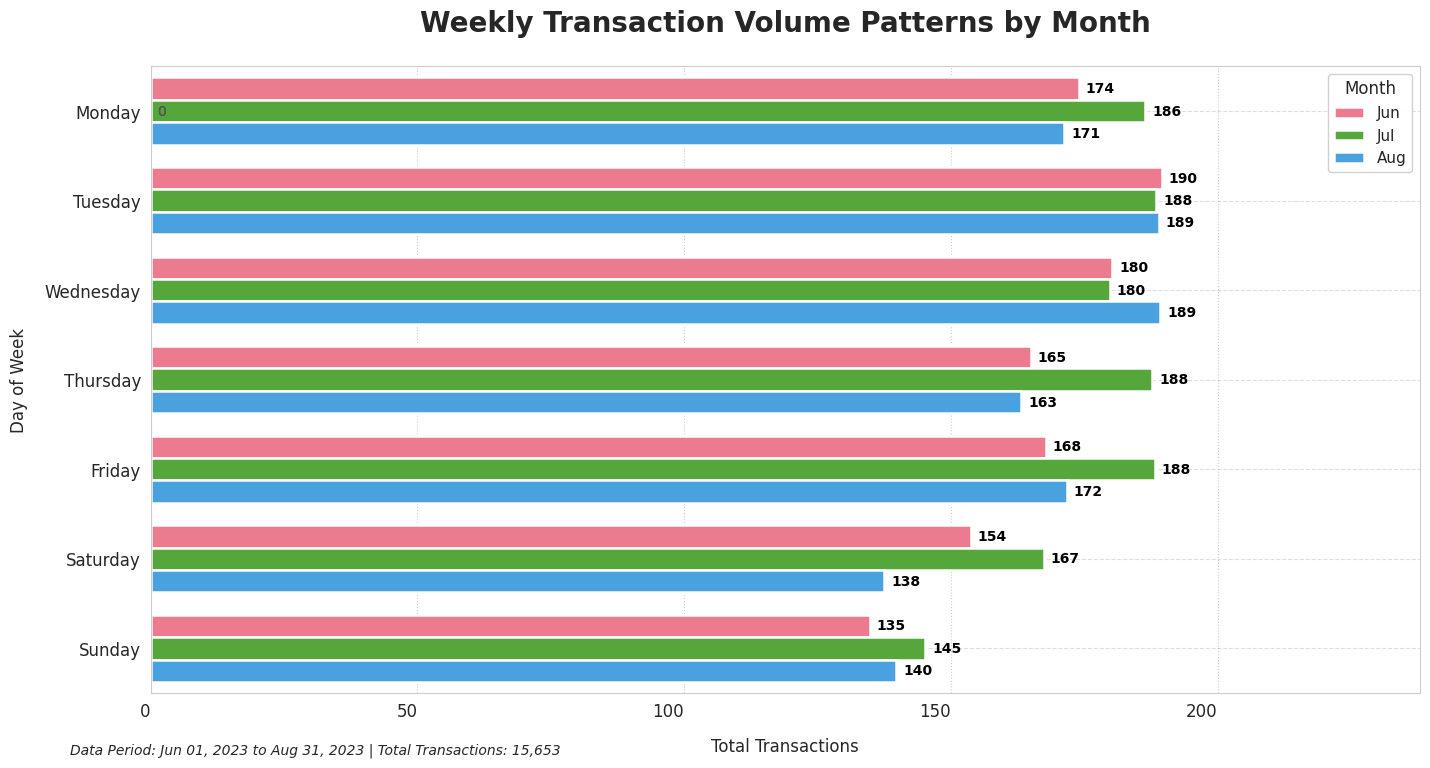

In [359]:
# @title
plt.figure(figsize=(16, 8), facecolor='white')

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
             'Friday', 'Saturday', 'Sunday']

month_palette = sns.color_palette("husl", 3)
month_names = ['Jun', 'Jul', 'Aug']

# Create the plot with improved parameters
ax = sns.barplot(
    x='count',
    y='day_name',
    data=trn_volume,
    order=day_order,
    palette=month_palette,
    saturation=0.85,
    edgecolor='white',
    linewidth=1.8,
    width=0.75,
    hue='month',
    err_kws={'linewidth': 0},
    orient='h'
)

# Title and labels with better spacing
plt.title('Weekly Transaction Volume Patterns by Month',
          fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Total Transactions', fontsize=12, labelpad=12)
plt.ylabel('Day of Week', fontsize=12, labelpad=12)

# Grid and frame styling
plt.grid(axis='y', linestyle='--', alpha=0.25, color='gray')
ax.set_axisbelow(True)

# Tick formatting
plt.xticks(ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Custom bar annotations
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    rotation_angle = 0
    va_adjustment = 5

    ax.annotate(
        f'{width:,.0f}',
        xy=(width, y),
        ha='left',
        va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=10,
        color='black' if width > max([p.get_width() for p in ax.patches])*0.4 else '#555555',
        weight='bold' if width > max([p.get_width() for p in ax.patches])*0.7 else 'normal',
        rotation=rotation_angle,
        rotation_mode='anchor'
    )

# Custom legend
handles, labels = ax.get_legend_handles_labels()
month_legend = plt.legend(
    handles[:3],  # Only show month entries
    month_names,
    title='Month',
    loc='upper right',
    frameon=True,
    framealpha=0.9,
    fontsize=11,
    title_fontsize=12
)

# Data source footnote with enhanced formatting
plt.figtext(0.2, 0.05,
           f"Data Period: {trn_volume['trn_dt'].min().strftime('%b %d, %Y')} to {trn_volume['trn_dt'].max().strftime('%b %d, %Y')} | "
           f"Total Transactions: {trn_volume['count'].sum():,.0f}",
           ha='center',
           fontsize=10,
           style='italic',
)

plt.tight_layout(rect=[0, 0.03, 0.9, 1])  # Adjust for legend
plt.show()

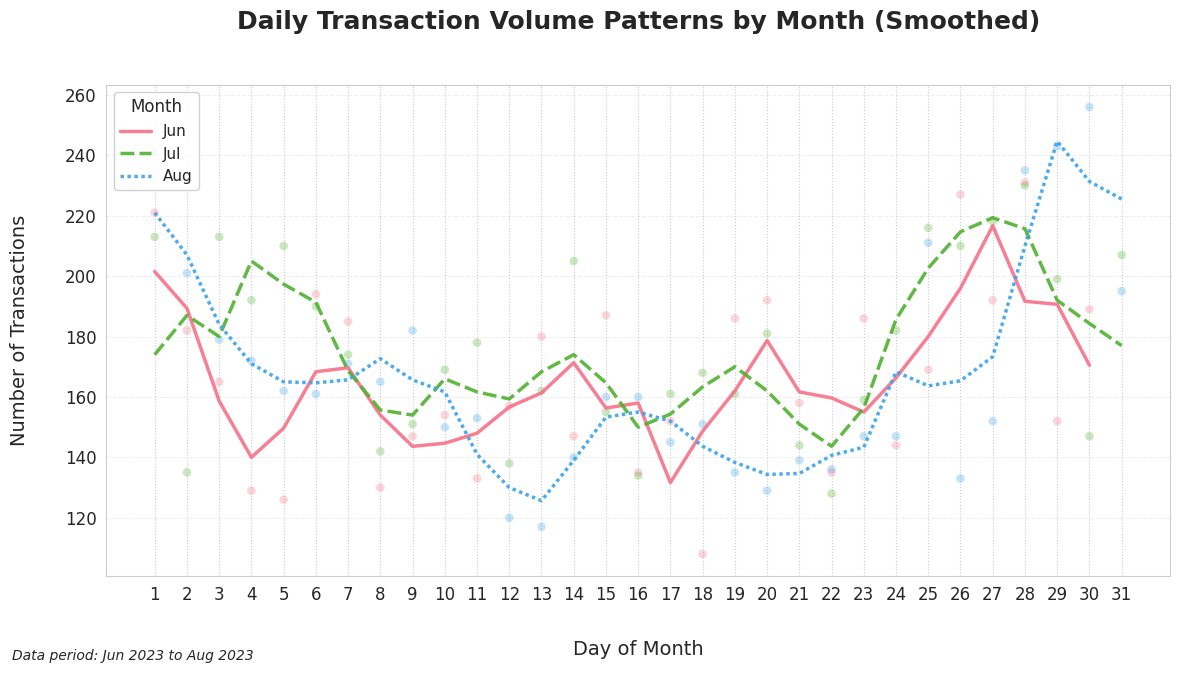

In [335]:
# @title
plt.figure(figsize=(14, 7), facecolor='white')

# Create a custom color palette for months
month_palette = sns.color_palette("husl", 3)
month_names = ['Jun', 'Jul', 'Aug']

# Apply 3-day rolling average for smoothing
trn_volume_smoothed = trn_volume.copy()
trn_volume_smoothed['count_smoothed'] = trn_volume.groupby('month')['count'].transform(
    lambda x: x.rolling(window=3, center=True, min_periods=1).mean()
)

# Plot with enhanced styling and smoothing
ax = sns.lineplot(
    data=trn_volume_smoothed,
    x='day',
    y='count_smoothed',
    hue='month',
    palette=month_palette,
    linewidth=2.5,
    style='month',
    alpha=0.9,
    estimator=None
)

# Add original points as semi-transparent markers
sns.scatterplot(
    data=trn_volume,
    x='day',
    y='count',
    hue='month',
    palette=month_palette,
    s=40,
    alpha=0.3,
    legend=False,
    ax=ax
)

# Enhancements
plt.title('Daily Transaction Volume Patterns by Month (Smoothed)\n',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('\nDay of Month', fontsize=14, labelpad=10)
plt.ylabel('Number of Transactions\n', fontsize=14, labelpad=10)

# Customize x-axis to show all days
plt.xticks(range(1, 32), fontsize=12)
plt.yticks(fontsize=12)

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

# Improve legend
handles, labels = ax.get_legend_handles_labels()
month_legend = plt.legend(
    handles[:3],  # Only show month entries
    month_names,
    title='Month',
    loc='upper left',
    frameon=True,
    framealpha=0.9,
    fontsize=11,
    title_fontsize=12
)

# Add data source footnote with smoothing note
plt.figtext(0.1, 0.05,
           f"Data period: {trn_volume['trn_dt'].min().strftime('%b %Y')} to {trn_volume['trn_dt'].max().strftime('%b %Y')} ",
           ha='center', fontsize=10, style='italic')

plt.tight_layout(rect=[0, 0.03, 0.85, 1])  # Adjust for legend
plt.show()

## Transaction Amount

In [336]:
# @title
trn_amt = df.groupby('trn_dt')['amt'].sum().reset_index(name='amount')
trn_amt['trn_dt'] = pd.to_datetime(trn_volume['trn_dt'])
trn_amt['month'] = trn_amt['trn_dt'].dt.month
trn_amt['week'] = trn_amt['trn_dt'].dt.isocalendar().week
trn_amt['day'] = trn_amt['trn_dt'].dt.day
trn_amt['day_name'] = trn_amt['trn_dt'].dt.day_name()
display(trn_amt.head())

,trn_dt,amount,month,week,day,day_name
0,2023-06-01,170654.94,6,22,1,Thursday
1,2023-06-02,165523.39,6,22,2,Friday
2,2023-06-03,119156.46,6,22,3,Saturday
3,2023-06-04,58579.07,6,22,4,Sunday
4,2023-06-05,67113.18,6,23,5,Monday


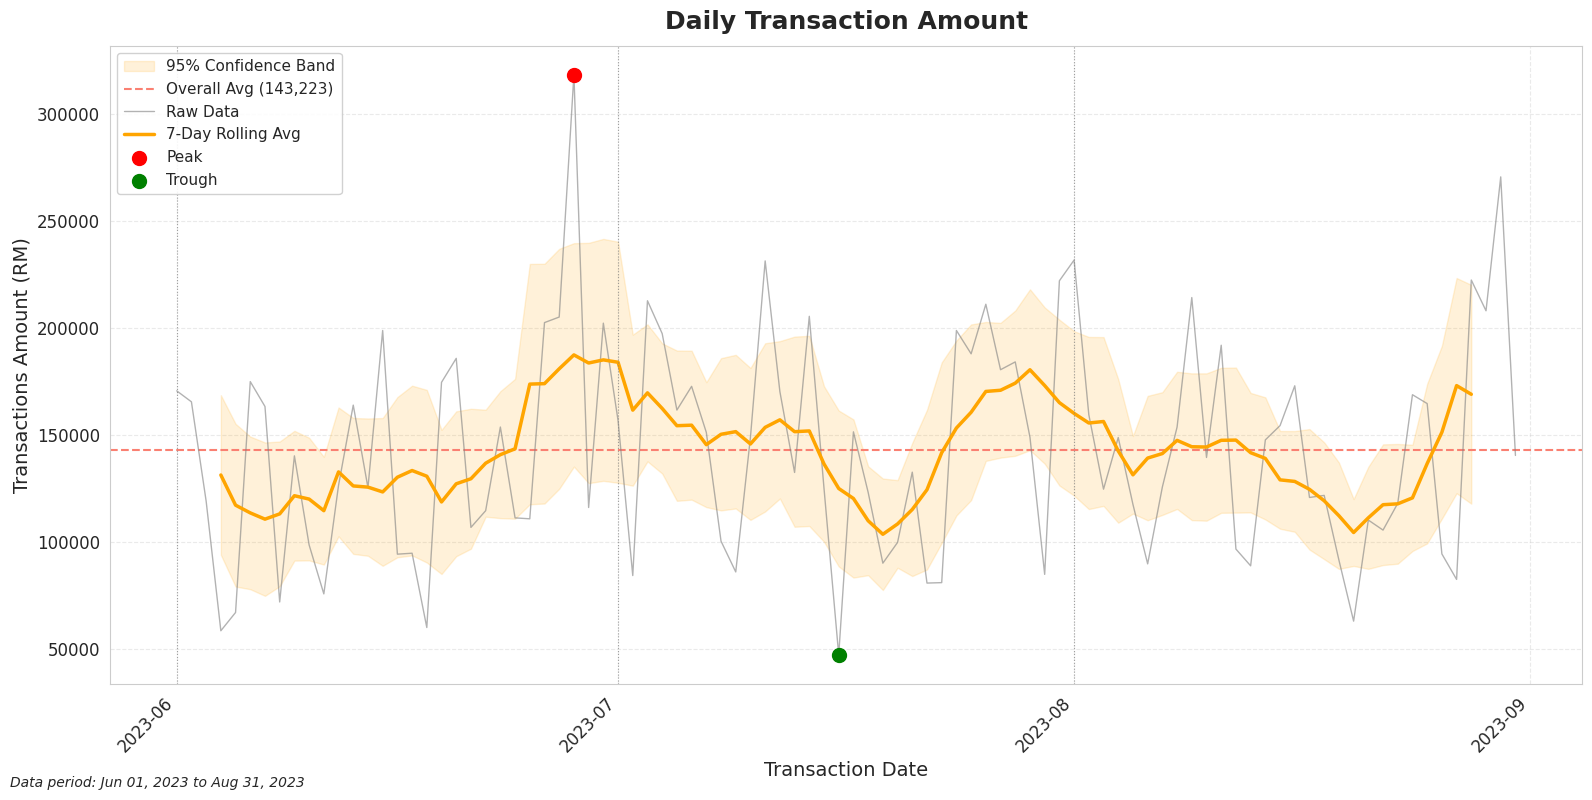

In [337]:
# @title
plt.figure(figsize=(16, 8), facecolor='white')

# --- Smoothing with Rolling Average & Confidence Band ---
window = 7
trn_amt['smoothed'] = trn_amt['amount'].rolling(window, center=True).mean()
trn_amt['std'] = trn_amt['amount'].rolling(window, center=True).std()
ci = 1.96 * trn_amt['std'] / (window**0.5)  # 95% CI

# Plot confidence band
plt.fill_between(trn_amt['trn_dt'],
                 trn_amt['smoothed'] - ci,
                 trn_amt['smoothed'] + ci,
                 color='orange', alpha=0.15, label='95% Confidence Band')

avg_amt = trn_amt['amount'].mean()
plt.axhline(y=avg_amt, color='salmon', linestyle='--', linewidth=1.5,
            label=f'Overall Avg ({avg_amt:,.0f})')

# --- Plot Raw vs. Smoothed ---
sns.lineplot(data=trn_amt, x='trn_dt', y='amount',
             color='gray', linewidth=1, alpha=0.6, label='Raw Data')
sns.lineplot(data=trn_amt, x='trn_dt', y='smoothed',
             color='orange', linewidth=2.5, label=f'{window}-Day Rolling Avg')

# --- Highlight Peaks & Troughs ---
max_idx = trn_amt['amount'].idxmax()
min_idx = trn_amt['amount'].idxmin()
plt.scatter(trn_amt.loc[max_idx, 'trn_dt'], trn_amt.loc[max_idx, 'amount'],
            color='red', s=100, zorder=5, label='Peak')
plt.scatter(trn_amt.loc[min_idx, 'trn_dt'], trn_amt.loc[min_idx, 'amount'],
            color='green', s=100, zorder=5, label='Trough')

# --- Add Vertical Lines for Month Starts ---
ax = plt.gca()
for date in pd.date_range(trn_amt['trn_dt'].min(), trn_amt['trn_dt'].max(), freq='MS'):
    ax.axvline(date, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
ax.xaxis.set_major_locator(mdates.MonthLocator())  # Ensure ticks align with lines

# --- Annotate Significant Events (Customize Dates) ---
events = {
    '2023-01-15': 'Promotion Campaign',
    '2023-03-10': 'System Outage'
}

for date_str, label in events.items():
    date = pd.to_datetime(date_str)
    if date in trn_amt['trn_dt'].values:
        y_val = trn_amt[trn_amt['trn_dt'] == date]['amount'].values[0]
        plt.annotate(label, xy=(date, y_val), xytext=(10, 20),
                     textcoords='offset points', arrowprops=dict(arrowstyle='->'),
                     bbox=dict(boxstyle='round',pad=0.5, fc='yellow', alpha=0.8))

# --- Formatting ---
plt.title('Daily Transaction Amount',
          fontsize=18, fontweight='bold', pad=12)
plt.xlabel('Transaction Date', fontsize=14)
plt.ylabel('Transactions Amount (RM)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=11, framealpha=0.9, loc='upper left')

# Footer with data range
plt.figtext(0.1, 0.01,
            f"Data period: {trn_amt['trn_dt'].min().strftime('%b %d, %Y')} to {trn_amt['trn_dt'].max().strftime('%b %d, %Y')}",
            ha='center', fontsize=10, style='italic')
plt.tight_layout()
plt.show()

In [338]:
# @title
max_idx = trn_amt['amount'].idxmax()
min_idx = trn_amt['amount'].idxmin()

# Get the peak dates from trn_volume
peak_date = trn_amt.loc[max_idx, 'trn_dt']  # Highest peak date
trough_date = trn_amt.loc[min_idx, 'trn_dt']  # Lowest peak date

# Get the peak count from trn_volume
peak_amt = trn_amt.loc[max_idx, 'amount']  # Highest peak count
trough_amt = trn_amt.loc[min_idx, 'amount']  # Lowest peak count

# Convert 'trn_dt' to datetime objects in the original DataFrame
df['trn_dt'] = pd.to_datetime(df['trn_dt'])

# Extract all transactions on these dates from your full DataFrame
peak_trn = df[df['trn_dt'].dt.date == peak_date.date()]
trough_trn = df[df['trn_dt'].dt.date == trough_date.date()]

# Display the results
print(f"\nTransactions on peak date ({peak_date.date()}) with RM{peak_amt}")
print(f"\nTransactions on trough date ({trough_date.date()}) with RM{trough_amt}")


Transactions on peak date (2023-06-28) with RM318345.72

Transactions on trough date (2023-07-16) with RM47245.9


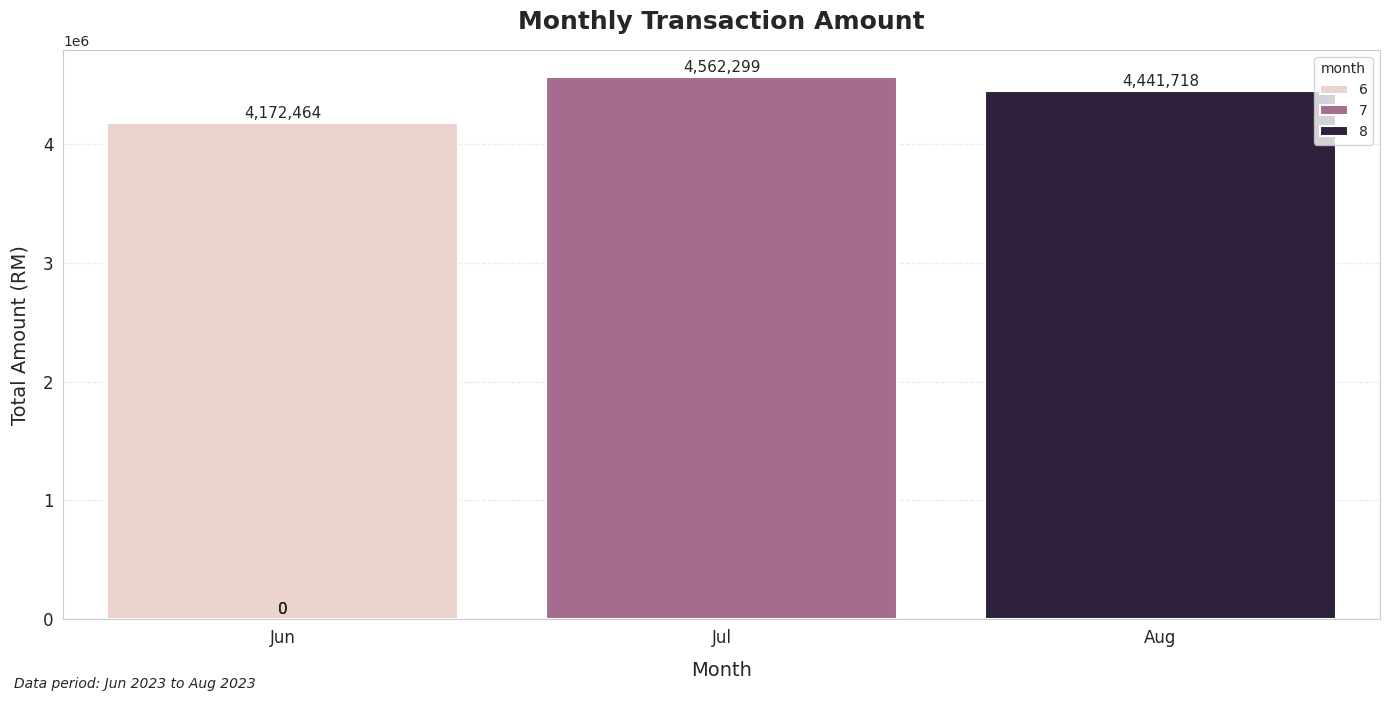

In [339]:
# @title
plt.figure(figsize=(14, 7), facecolor='white')

ax = sns.barplot(
    x='month',
    y='amount',
    data=trn_amt.groupby('month')['amount'].sum().reset_index(),
    hue='month',
    saturation=0.85,
    edgecolor='white',
    linewidth=1.5
)

plt.title('Monthly Transaction Amount',
          fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=14, labelpad=10)
plt.ylabel('Total Amount (RM)', fontsize=14, labelpad=10)

plt.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.xticks(range(3), ['Jun', 'Jul', 'Aug'],
           fontsize=12)
plt.yticks(fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 7),
                textcoords='offset points',
                fontsize=11)

plt.figtext(0.1, 0.01,
           f"Data period: {trn_amt['trn_dt'].min().strftime('%b %Y')} to {trn_amt['trn_dt'].max().strftime('%b %Y')}",
           ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

<ipython-input-362-ef4081aa87ae>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


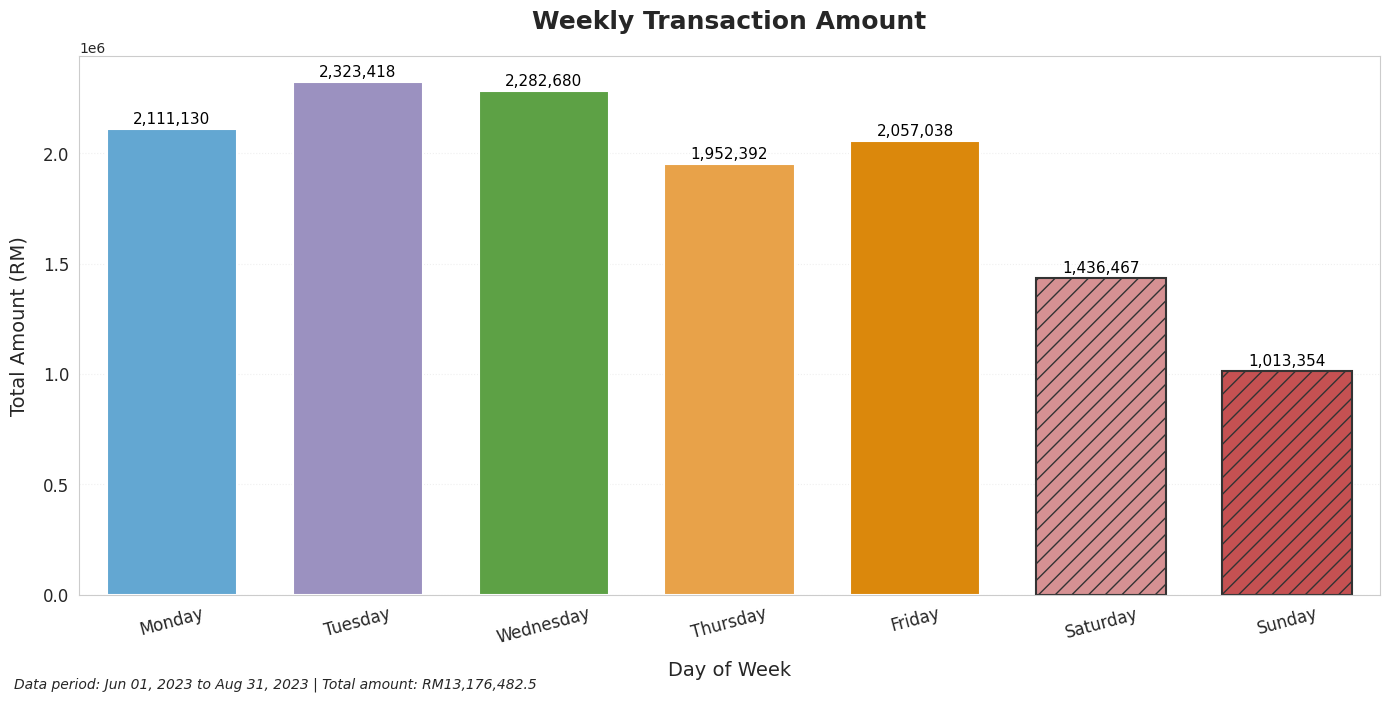

In [362]:
# @title
plt.figure(figsize=(14, 7), facecolor='white')

palette = ['#5DA8D8', '#998EC3', '#5BA640', '#F1A340',
           '#E68A00', '#DA8D8F', '#CB4B4C']

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
             'Friday', 'Saturday', 'Sunday']

ax = sns.barplot(
    x='day_name',
    y='amount',
    data=trn_amt.groupby('day_name')['amount'].sum().reset_index(),
    order=day_order,
    palette=palette,
    saturation=0.9,
    edgecolor='white',
    linewidth=1.5,
    width=0.7
)

plt.title('Weekly Transaction Amount',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Day of Week', fontsize=14, labelpad=10)
plt.ylabel('Total Amount (RM)', fontsize=14, labelpad=10)

plt.grid(axis='y', linestyle=':', alpha=0.3)
ax.set_axisbelow(True)

plt.xticks(fontsize=12, rotation=15)
plt.yticks(fontsize=12)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom' if p.get_height() < max([p.get_height() for p in ax.patches])*0.1 else 'center',
        xytext=(0, 7),
        textcoords='offset points',
        fontsize=11,
        color='black' if p.get_height() > max([p.get_height() for p in ax.patches])*0.3 else 'gray'
    )

for i, day in enumerate(day_order):
    if day in ['Saturday', 'Sunday']:
        ax.patches[i].set_hatch('//')
        ax.patches[i].set_edgecolor('#333333')

plt.figtext(0.2, 0.01,
           f"Data period: {trn_amt['trn_dt'].min().strftime('%b %d, %Y')} to {trn_amt['trn_dt'].max().strftime('%b %d, %Y')} | Total amount: RM{trn_amt['amount'].sum():,}",
           ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

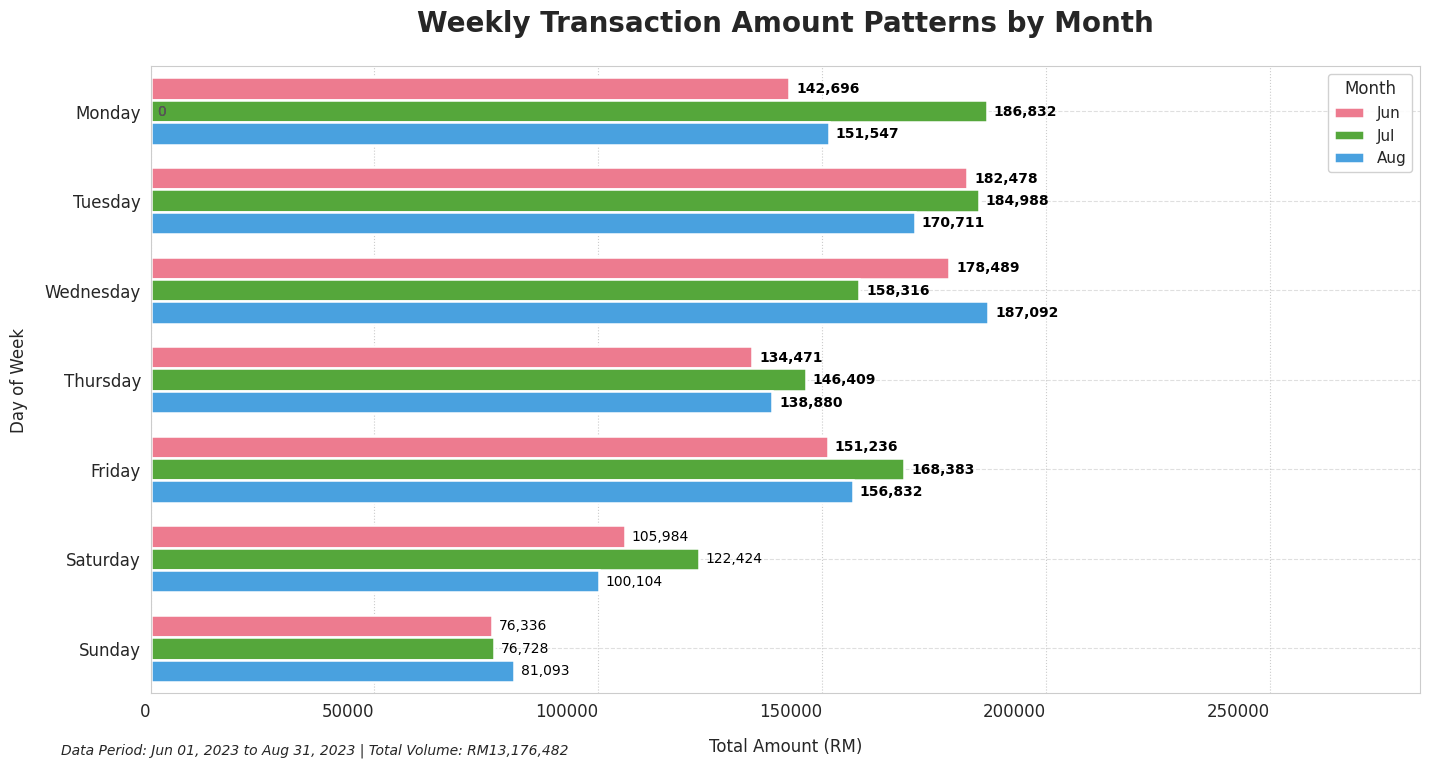

In [341]:
# @title
plt.figure(figsize=(16, 8), facecolor='white')

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
             'Friday', 'Saturday', 'Sunday']

month_palette = sns.color_palette("husl", 3)
month_names = ['Jun', 'Jul', 'Aug']

# Create the plot with improved parameters
ax = sns.barplot(
    x='amount',
    y='day_name',
    data=trn_amt,
    order=day_order,
    palette=month_palette,
    saturation=0.85,
    edgecolor='white',
    linewidth=1.8,
    width=0.75,
    hue='month',
    err_kws={'linewidth': 0},
    orient='h'
)

# Title and labels with better spacing
plt.title('Weekly Transaction Amount Patterns by Month',
          fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Total Amount (RM)', fontsize=12, labelpad=12)
plt.ylabel('Day of Week', fontsize=12, labelpad=12)

# Grid and frame styling
plt.grid(axis='y', linestyle='--', alpha=0.25, color='gray')
ax.set_axisbelow(True)

# Tick formatting
plt.xticks(ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Custom bar annotations
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    rotation_angle = 0
    va_adjustment = 5

    ax.annotate(
        f'{width:,.0f}',
        xy=(width, y),
        ha='left',
        va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=10,
        color='black' if width > max([p.get_width() for p in ax.patches])*0.4 else '#555555',
        weight='bold' if width > max([p.get_width() for p in ax.patches])*0.7 else 'normal',
        rotation=rotation_angle,
        rotation_mode='anchor'
    )

# Custom legend
handles, labels = ax.get_legend_handles_labels()
month_legend = plt.legend(
    handles[:3],  # Only show month entries
    month_names,
    title='Month',
    loc='upper right',
    frameon=True,
    framealpha=0.9,
    fontsize=11,
    title_fontsize=12
)

# Data source footnote with enhanced formatting
plt.figtext(0.2, 0.05,
           f"Data Period: {trn_amt['trn_dt'].min().strftime('%b %d, %Y')} to {trn_amt['trn_dt'].max().strftime('%b %d, %Y')} | "
           f"Total Volume: RM{trn_amt['amount'].sum():,.0f}",
           ha='center',
           fontsize=10,
           style='italic',
)

plt.tight_layout(rect=[0, 0.03, 0.9, 1])  # Adjust for legend
plt.show()

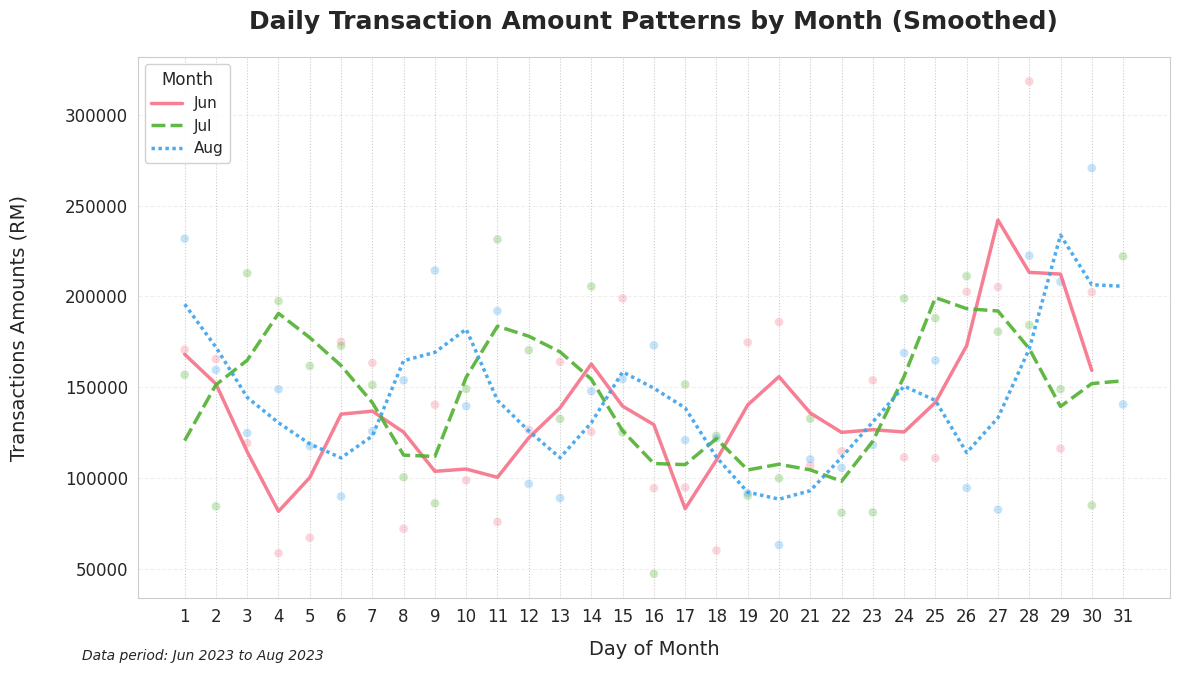

In [342]:
# @title
plt.figure(figsize=(14, 7), facecolor='white')

# Create a custom color palette for months
month_palette = sns.color_palette("husl", 3)
month_names = ['Jun', 'Jul', 'Aug']

# Apply 3-day rolling average for smoothing
trn_amt_smoothed = trn_amt.copy()
trn_amt_smoothed['amount_smoothed'] = trn_amt.groupby('month')['amount'].transform(
    lambda x: x.rolling(window=3, center=True, min_periods=1).mean()
)

# Plot with enhanced styling and smoothing
ax = sns.lineplot(
    data=trn_amt_smoothed,
    x='day',
    y='amount_smoothed',  # Use smoothed values
    hue='month',
    palette=month_palette,
    linewidth=2.5,  # Slightly thicker lines
    style='month',
    alpha=0.9,
    estimator=None  # Ensure we're plotting actual values, not aggregating
)

# Add original points as semi-transparent markers
sns.scatterplot(
    data=trn_amt_smoothed,
    x='day',
    y='amount',
    hue='month',
    palette=month_palette,
    s=40,  # Smaller markers
    alpha=0.3,  # More transparent
    legend=False,
    ax=ax
)

# Enhancements
plt.title('Daily Transaction Amount Patterns by Month (Smoothed)',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Day of Month', fontsize=14, labelpad=10)
plt.ylabel('Transactions Amounts (RM)\n', fontsize=14, labelpad=10)

# Customize x-axis to show all days
plt.xticks(range(1, 32), fontsize=12)
plt.yticks(fontsize=12)

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

# Improve legend
handles, labels = ax.get_legend_handles_labels()
month_legend = plt.legend(
    handles[:3],  # Only show month entries
    month_names,
    title='Month',
    loc='upper left',
    frameon=True,
    framealpha=0.9,
    fontsize=11,
    title_fontsize=12
)

# Add data source footnote with smoothing note
plt.figtext(0.15, 0.05,
           f"Data period: {trn_amt['trn_dt'].min().strftime('%b %Y')} to {trn_amt['trn_dt'].max().strftime('%b %Y')} ",
           ha='center', fontsize=10, style='italic')

plt.tight_layout(rect=[0, 0.03, 0.85, 1])  # Adjust for legend
plt.show()

## More into Transaction Type, Channel and Description

In [343]:
# @title
transactions_per_customer = df.groupby(['cus_no', 'trn_type', 'trn_desc', 'chn']).size().reset_index(name='txn_count')
display(transactions_per_customer.head())

,cus_no,trn_type,trn_desc,chn,txn_count
0,1027661837,CREDIT,CDEP,BRNCH / ATM,8
1,1027661837,CREDIT,IBK,Unknown,4
2,1027661837,CREDIT,SALARY,Unknown,3
3,1027661837,DEBIT,FUND TRANSFER,IB,25
4,1027661837,DEBIT,PAYMENT,IB,1


In [344]:
# @title
transactions_amt_per_customer = df.groupby(['cus_no', 'trn_type', 'trn_desc', 'chn'])['amt'].sum().reset_index(name='amount')
display(transactions_amt_per_customer.head())

,cus_no,trn_type,trn_desc,chn,amount
0,1027661837,CREDIT,CDEP,BRNCH / ATM,39650.00
1,1027661837,CREDIT,IBK,Unknown,13093.75
2,1027661837,CREDIT,SALARY,Unknown,14728.40
3,1027661837,DEBIT,FUND TRANSFER,IB,37375.90
4,1027661837,DEBIT,PAYMENT,IB,613.19


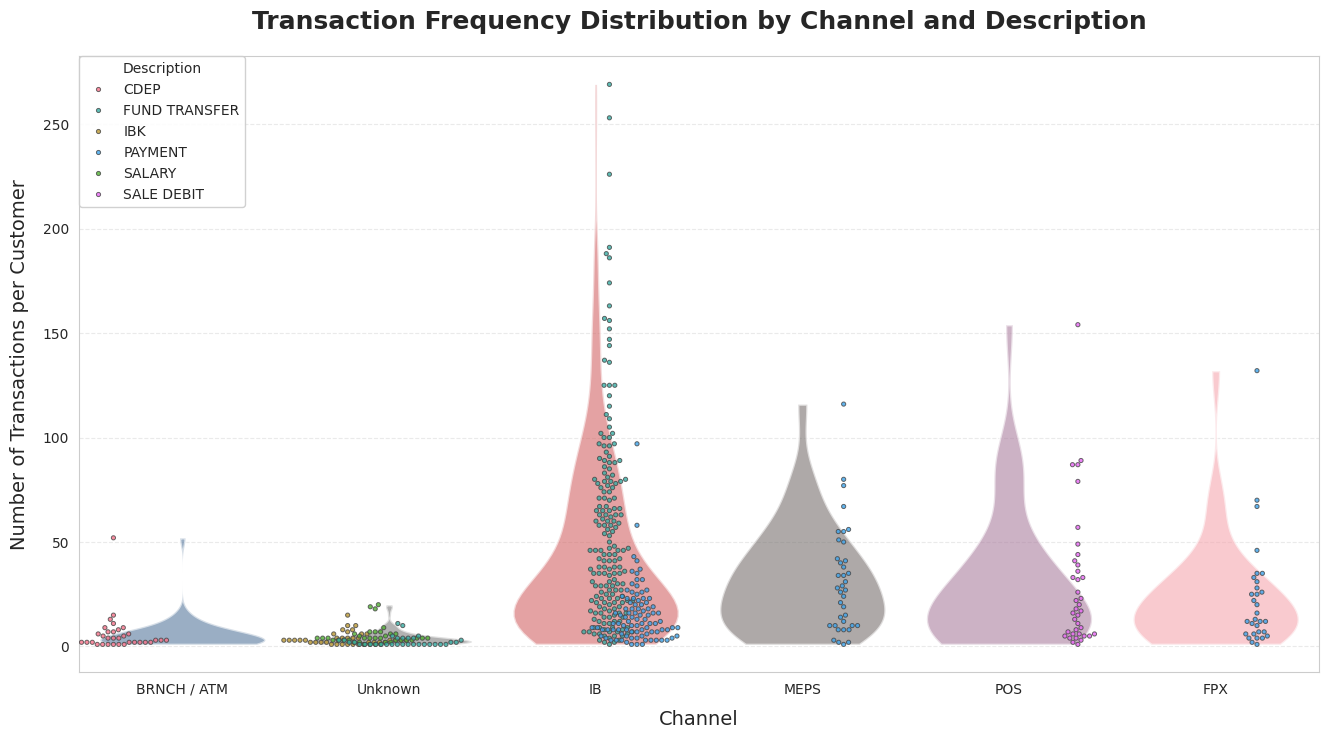

In [363]:
# @title
plt.figure(figsize=(16, 8), facecolor='white')

# Create a more distinct palette with better contrast
palette = {
    'BRNCH / ATM': '#4E79A7',
    'ATM': '#59A14F',
    'IB': '#E15759',
    'MEPS': '#79706E',
    'POS': '#B07AA1',
    'FPX': '#FF9DA7',
    'Unknown' : 'GREY'
}

# Create violin plot
ax = sns.violinplot(
    data=transactions_per_customer,
    x="chn",
    y="txn_count",
    hue="chn",
    palette=palette,
    inner=None,
    density_norm="area",
    alpha=0.6,
    cut=0,
    linewidth=1.8,
    edgecolor='white',
    saturation=0.8,
    width=0.8,
    ax=plt.gca()
)

# Add swarm plot showing transaction descriptions
swarm = sns.swarmplot(
    data=transactions_per_customer,
    x="chn",
    y="txn_count",
    hue="trn_desc",
    palette="husl",
    size=3,
    linewidth=0.7,
    alpha=0.8,
    dodge=True,
    ax=ax
)

# Enhancements (using ax for explicit control)
ax.set_title('Transaction Frequency Distribution by Channel and Description',
              fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Channel', fontsize=14, labelpad=10)
ax.set_ylabel('Number of Transactions per Customer', fontsize=14, labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.4) # Use ax.grid
ax.set_axisbelow(True) # Ensure grid lines are behind plot elements

type_handles, type_labels = ax.get_legend_handles_labels()
type_handles = type_handles[:len(palette)]
type_labels = [label for label in type_labels if label in palette.keys()]

# Get handles and labels for transaction descriptions (from the swarm plot's hue)
if ax.legend_ is not None:
    ax.legend_.remove()

# Create the second legend for Description (from swarm plot)
desc_handles, desc_labels = swarm.get_legend_handles_labels()

# Ensure unique descriptions are ordered as in the plot if possible, or sorted
unique_descriptions_sorted = sorted(transactions_per_customer['trn_desc'].unique())
desc_handles_filtered = []
desc_labels_filtered = []
for desc in unique_descriptions_sorted:
    try:
        idx = desc_labels.index(desc)
        desc_handles_filtered.append(desc_handles[idx])
        desc_labels_filtered.append(desc_labels[idx])
    except ValueError:
        pass # Handle case where a label might not be found

legend2 = ax.legend(
    handles=desc_handles_filtered, # Use filtered handles
    labels=desc_labels_filtered,   # Use filtered labels
    title='Description',
    loc='upper left',
    framealpha=0.9,
    borderaxespad=0.
)

# Adjust layout to make space for legends and footnote
plt.show()

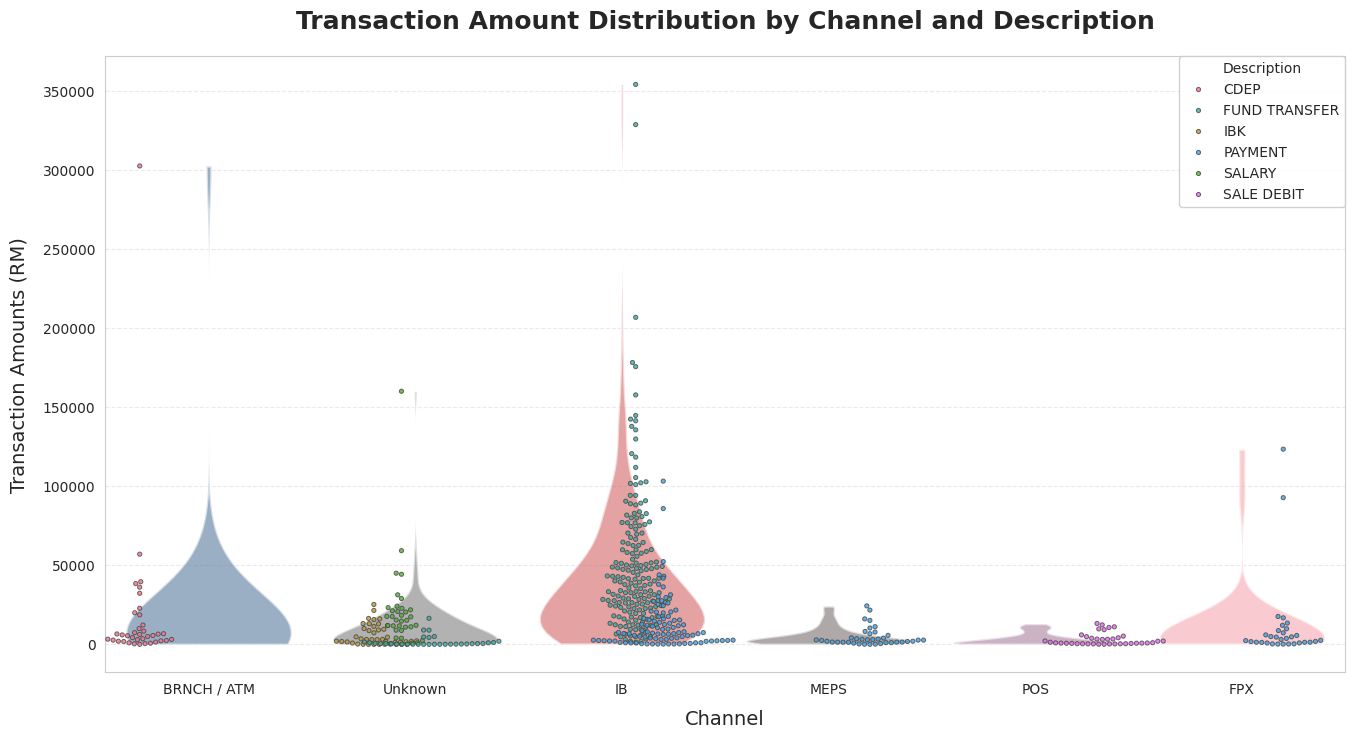

In [364]:
# @title
plt.figure(figsize=(16, 8), facecolor='white')

# Create a more distinct palette with better contrast
palette = {
    'BRNCH / ATM': '#4E79A7',
    'ATM': '#59A14F',
    'IB': '#E15759',
    'MEPS': '#79706E',
    'POS': '#B07AA1',
    'FPX': '#FF9DA7',
    'Unknown' : 'GREY'
}

# Create violin plot
ax = sns.violinplot(
    data=transactions_amt_per_customer,
    x="chn",
    y="amount",
    hue="chn",
    palette=palette,
    inner=None,
    density_norm="area",
    alpha=0.6,
    cut=0,
    linewidth=1.8,
    edgecolor='white',
    saturation=0.8,
    width=0.8,
    ax=plt.gca()
)

# Add swarm plot showing transaction descriptions
swarm = sns.swarmplot(
    data=transactions_amt_per_customer,
    x="chn",
    y="amount",
    hue="trn_desc",
    palette="husl",
    size=3,
    linewidth=0.7,
    alpha=0.8,
    dodge=True,
    ax=ax
)

# Enhancements (using ax for explicit control)
ax.set_title('Transaction Amount Distribution by Channel and Description',
              fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Channel', fontsize=14, labelpad=10)
ax.set_ylabel('Transaction Amounts (RM)', fontsize=14, labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.4) # Use ax.grid
ax.set_axisbelow(True) # Ensure grid lines are behind plot elements

type_handles, type_labels = ax.get_legend_handles_labels()
type_handles = type_handles[:len(palette)]
type_labels = [label for label in type_labels if label in palette.keys()]

# Get handles and labels for transaction descriptions (from the swarm plot's hue)
if ax.legend_ is not None:
    ax.legend_.remove()

# Create the second legend for Description (from swarm plot)
desc_handles, desc_labels = swarm.get_legend_handles_labels()

# Ensure unique descriptions are ordered as in the plot if possible, or sorted
unique_descriptions_sorted = sorted(transactions_amt_per_customer['trn_desc'].unique())
desc_handles_filtered = []
desc_labels_filtered = []
for desc in unique_descriptions_sorted:
    try:
        idx = desc_labels.index(desc)
        desc_handles_filtered.append(desc_handles[idx])
        desc_labels_filtered.append(desc_labels[idx])
    except ValueError:
        pass # Handle case where a label might not be found

legend2 = ax.legend(
    handles=desc_handles_filtered, # Use filtered handles
    labels=desc_labels_filtered,   # Use filtered labels
    title='Description',
    loc='upper right',
    framealpha=0.9,
    borderaxespad=0.
)

# Adjust layout to make space for legends and footnote
plt.show()

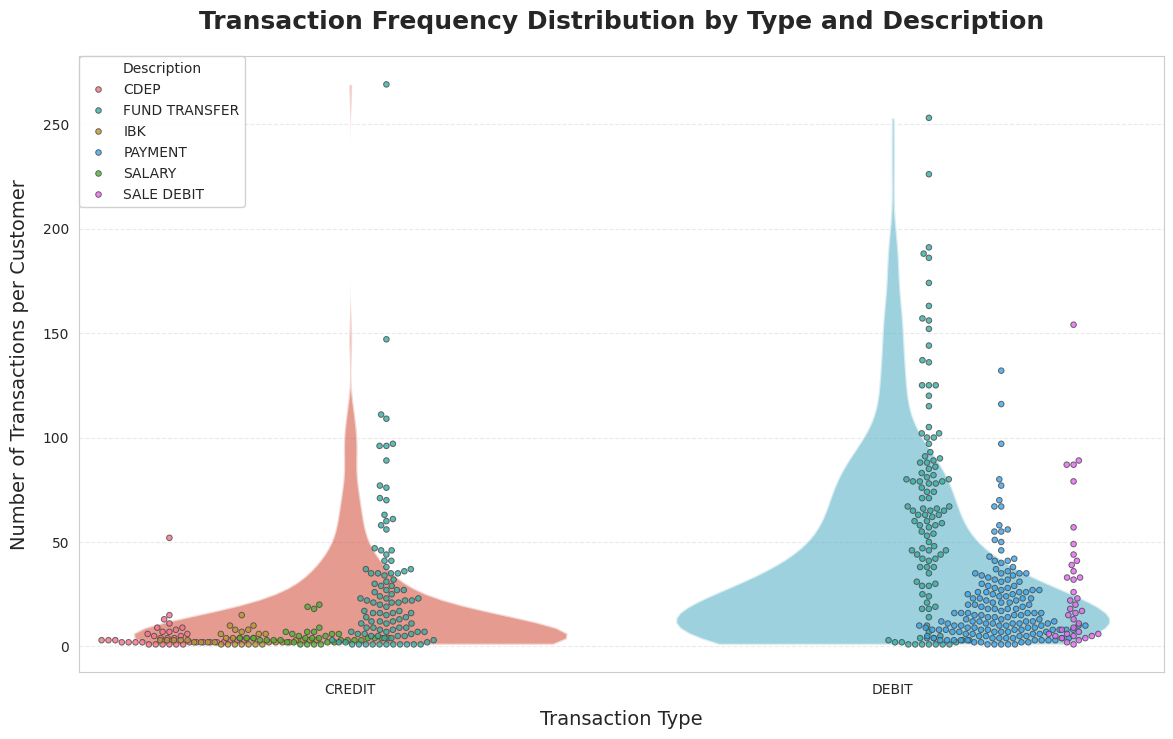

In [347]:
# @title
# Custom palette (consistent with previous plots)
palette = {"DEBIT": "#4DBBD5", "CREDIT": "#E64B35"}

plt.figure(figsize=(14, 8), facecolor='white')

# Create violin plot
ax = sns.violinplot(
    data=transactions_per_customer,
    x="trn_type",
    y="txn_count",
    hue="trn_type",
    palette=palette,
    inner=None,
    density_norm="area",
    alpha=0.6,
    cut=0,
    linewidth=1.8,
    edgecolor='white',
    saturation=0.8,
    width=0.8,
    ax=plt.gca()
)

# Add swarm plot showing transaction descriptions
swarm = sns.swarmplot(
    data=transactions_per_customer,
    x="trn_type",
    y="txn_count",
    hue="trn_desc",
    palette="husl",
    size=4,
    linewidth=0.7,
    alpha=0.8,
    dodge=True,
    ax=ax
)

# Enhancements (using ax for explicit control)
ax.set_title('Transaction Frequency Distribution by Type and Description',
              fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Transaction Type', fontsize=14, labelpad=10)
ax.set_ylabel('Number of Transactions per Customer', fontsize=14, labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.4) # Use ax.grid
ax.set_axisbelow(True) # Ensure grid lines are behind plot elements

type_handles, type_labels = ax.get_legend_handles_labels()
type_handles = type_handles[:len(palette)]
type_labels = [label for label in type_labels if label in palette.keys()]

# Get handles and labels for transaction descriptions (from the swarm plot's hue)
if ax.legend_ is not None:
    ax.legend_.remove()

# Create the second legend for Description (from swarm plot)
desc_handles, desc_labels = swarm.get_legend_handles_labels()

# Ensure unique descriptions are ordered as in the plot if possible, or sorted
unique_descriptions_sorted = sorted(transactions_per_customer['trn_desc'].unique())
desc_handles_filtered = []
desc_labels_filtered = []
for desc in unique_descriptions_sorted:
    try:
        idx = desc_labels.index(desc)
        desc_handles_filtered.append(desc_handles[idx])
        desc_labels_filtered.append(desc_labels[idx])
    except ValueError:
        pass # Handle case where a label might not be found

legend2 = ax.legend(
    handles=desc_handles_filtered, # Use filtered handles
    labels=desc_labels_filtered,   # Use filtered labels
    title='Description',
    loc='upper left',
    framealpha=0.9,
    borderaxespad=0.
)

# Adjust layout to make space for legends and footnote
plt.show()

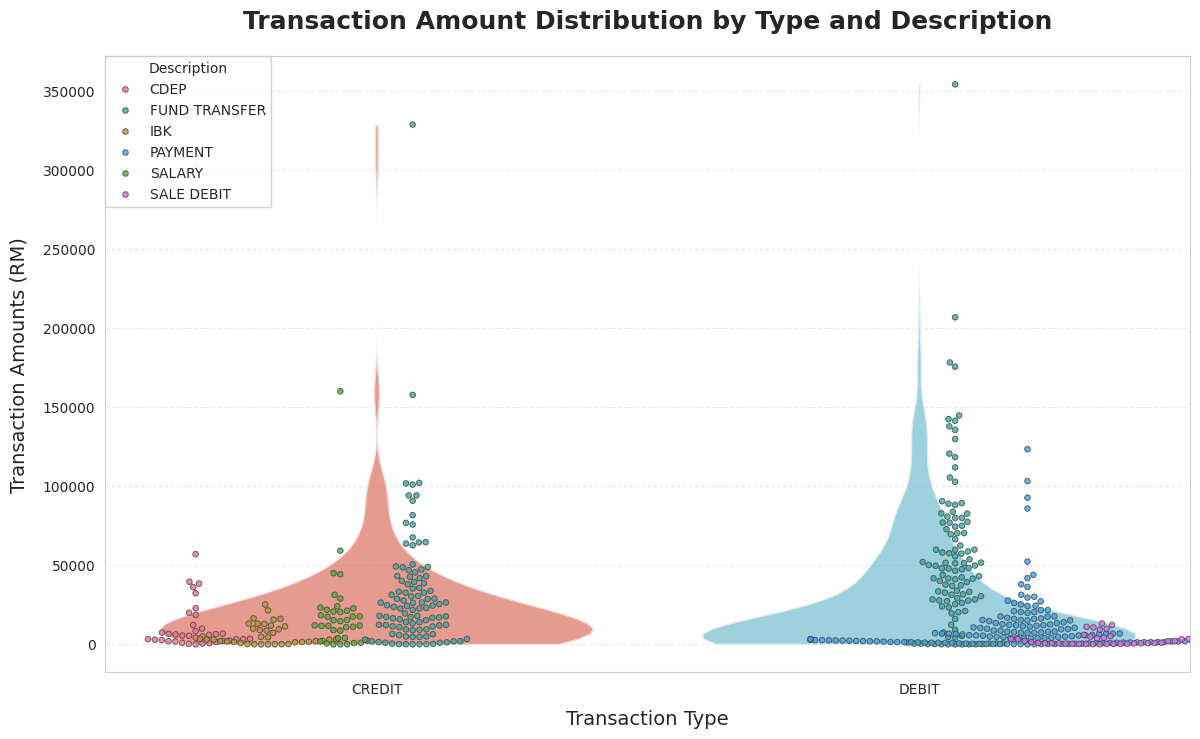

In [348]:
# @title
# Custom palette (consistent with previous plots)
palette = {"DEBIT": "#4DBBD5", "CREDIT": "#E64B35"}

plt.figure(figsize=(14, 8), facecolor='white')

# Create violin plot
ax = sns.violinplot(
    data=transactions_amt_per_customer,
    x="trn_type",
    y="amount",
    hue="trn_type",
    palette=palette,
    inner=None,
    density_norm="area",
    alpha=0.6,
    cut=0,
    linewidth=1.8,
    edgecolor='white',
    saturation=0.8,
    width=0.8,
    ax=plt.gca()
)

# Add swarm plot showing transaction descriptions
swarm = sns.swarmplot(
    data=transactions_amt_per_customer,
    x="trn_type",
    y="amount",
    hue="trn_desc",
    palette="husl",
    size=4,
    linewidth=0.7,
    alpha=0.8,
    dodge=True,
    ax=ax
)

# Enhancements (using ax for explicit control)
ax.set_title('Transaction Amount Distribution by Type and Description',
              fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Transaction Type', fontsize=14, labelpad=10)
ax.set_ylabel('Transaction Amounts (RM)', fontsize=14, labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.4) # Use ax.grid
ax.set_axisbelow(True) # Ensure grid lines are behind plot elements

type_handles, type_labels = ax.get_legend_handles_labels()
type_handles = type_handles[:len(palette)]
type_labels = [label for label in type_labels if label in palette.keys()]

# Get handles and labels for transaction descriptions (from the swarm plot's hue)
if ax.legend_ is not None:
    ax.legend_.remove()

# Create the second legend for Description (from swarm plot)
desc_handles, desc_labels = swarm.get_legend_handles_labels()

# Ensure unique descriptions are ordered as in the plot if possible, or sorted
unique_descriptions_sorted = sorted(transactions_amt_per_customer['trn_desc'].unique())
desc_handles_filtered = []
desc_labels_filtered = []
for desc in unique_descriptions_sorted:
    try:
        idx = desc_labels.index(desc)
        desc_handles_filtered.append(desc_handles[idx])
        desc_labels_filtered.append(desc_labels[idx])
    except ValueError:
        pass # Handle case where a label might not be found

legend2 = ax.legend(
    handles=desc_handles_filtered,
    labels=desc_labels_filtered,
    title='Description',
    loc='upper left',
    framealpha=0.9,
    borderaxespad=0.
)

# Adjust layout to make space for legends and footnote
plt.show()

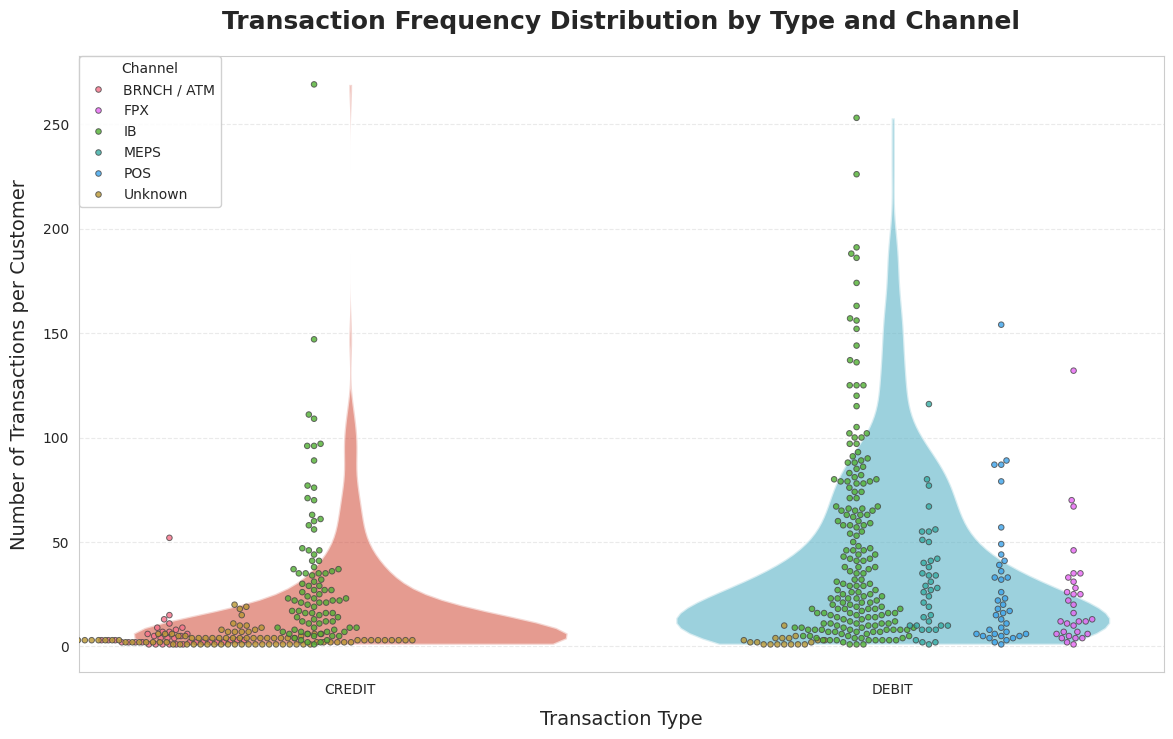

In [349]:
# @title
# Custom palette (consistent with previous plots)
palette = {"DEBIT": "#4DBBD5", "CREDIT": "#E64B35"}

plt.figure(figsize=(14, 8), facecolor='white')

# Create violin plot
ax = sns.violinplot(
    data=transactions_per_customer,
    x="trn_type",
    y="txn_count",
    hue="trn_type",
    palette=palette,
    inner=None,
    density_norm="area",
    alpha=0.6,
    cut=0,
    linewidth=1.8,
    edgecolor='white',
    saturation=0.8,
    width=0.8,
    ax=plt.gca()
)

# Add swarm plot showing transaction descriptions
swarm = sns.swarmplot(
    data=transactions_per_customer,
    x="trn_type",
    y="txn_count",
    hue="chn",
    palette="husl",
    size=4,
    linewidth=0.7,
    alpha=0.8,
    dodge=True,
    ax=ax
)

# Enhancements (using ax for explicit control)
ax.set_title('Transaction Frequency Distribution by Type and Channel',
              fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Transaction Type', fontsize=14, labelpad=10)
ax.set_ylabel('Number of Transactions per Customer', fontsize=14, labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.4) # Use ax.grid
ax.set_axisbelow(True) # Ensure grid lines are behind plot elements

type_handles, type_labels = ax.get_legend_handles_labels()
type_handles = type_handles[:len(palette)]
type_labels = [label for label in type_labels if label in palette.keys()]

# Get handles and labels for transaction descriptions (from the swarm plot's hue)
if ax.legend_ is not None:
    ax.legend_.remove()

# Create the second legend for Description (from swarm plot)
desc_handles, desc_labels = swarm.get_legend_handles_labels()

# Ensure unique descriptions are ordered as in the plot if possible, or sorted
unique_descriptions_sorted = sorted(transactions_per_customer['chn'].unique())
desc_handles_filtered = []
desc_labels_filtered = []
for desc in unique_descriptions_sorted:
    try:
        idx = desc_labels.index(desc)
        desc_handles_filtered.append(desc_handles[idx])
        desc_labels_filtered.append(desc_labels[idx])
    except ValueError:
        pass # Handle case where a label might not be found

legend2 = ax.legend(
    handles=desc_handles_filtered, # Use filtered handles
    labels=desc_labels_filtered,   # Use filtered labels
    title='Channel',
    loc='upper left',
    framealpha=0.9,
    borderaxespad=0.
)

plt.show()

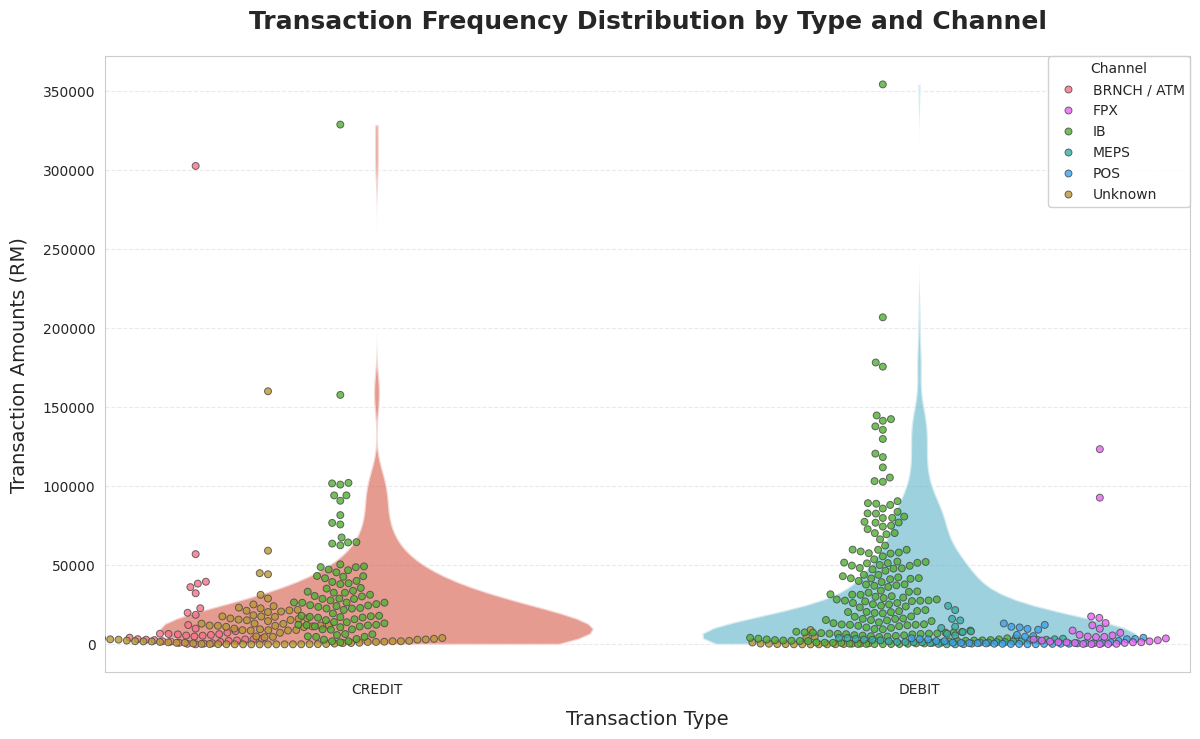

In [350]:
# @title
# Custom palette (consistent with previous plots)
palette = {"DEBIT": "#4DBBD5", "CREDIT": "#E64B35"}

plt.figure(figsize=(14, 8), facecolor='white')

# Create violin plot
ax = sns.violinplot(
    data=transactions_amt_per_customer,
    x="trn_type",
    y="amount",
    hue="trn_type",
    palette=palette,
    inner=None,
    density_norm="area",
    alpha=0.6,
    cut=0,
    linewidth=1.8,
    edgecolor='white',
    saturation=0.8,
    width=0.8,
    ax=plt.gca()
)

# Add swarm plot showing transaction descriptions
swarm = sns.swarmplot(
    data=transactions_amt_per_customer,
    x="trn_type",
    y="amount",
    hue="chn",
    palette="husl",
    size=5,
    linewidth=0.7,
    alpha=0.8,
    dodge=True,
    ax=ax
)

# Enhancements (using ax for explicit control)
ax.set_title('Transaction Frequency Distribution by Type and Channel',
              fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Transaction Type', fontsize=14, labelpad=10)
ax.set_ylabel('Transaction Amounts (RM)', fontsize=14, labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.4) # Use ax.grid
ax.set_axisbelow(True) # Ensure grid lines are behind plot elements

type_handles, type_labels = ax.get_legend_handles_labels()
type_handles = type_handles[:len(palette)]
type_labels = [label for label in type_labels if label in palette.keys()]

# Get handles and labels for transaction descriptions (from the swarm plot's hue)
if ax.legend_ is not None:
    ax.legend_.remove()

# Create the second legend for Description (from swarm plot)
desc_handles, desc_labels = swarm.get_legend_handles_labels()

# Ensure unique descriptions are ordered as in the plot if possible, or sorted
unique_descriptions_sorted = sorted(transactions_amt_per_customer['chn'].unique())
desc_handles_filtered = []
desc_labels_filtered = []
for desc in unique_descriptions_sorted:
    try:
        idx = desc_labels.index(desc)
        desc_handles_filtered.append(desc_handles[idx])
        desc_labels_filtered.append(desc_labels[idx])
    except ValueError:
        pass # Handle case where a label might not be found

legend2 = ax.legend(
    handles=desc_handles_filtered, # Use filtered handles
    labels=desc_labels_filtered,   # Use filtered labels
    title='Channel',
    loc='upper right',
    framealpha=0.9,
    borderaxespad=0.
)

plt.show()

## Branch

In [351]:
# @title
trn_brn = df.groupby(['brn_cd']).size().reset_index(name='count')
display(trn_brn.head())

,brn_cd,count
0,143953,2
1,162870,30
2,196386,10
3,226904,1
4,249407,2


In [352]:
# @title
amounts_brn = df.groupby('brn_cd')['amt'].sum().reset_index(name='total_amount')
trn_brn = trn_brn.merge(amounts_brn, on='brn_cd', how='left')
display(trn_brn.head())

,brn_cd,count,total_amount
0,143953,2,3000.00
1,162870,30,63215.91
2,196386,10,18382.00
3,226904,1,4000.00
4,249407,2,6000.00


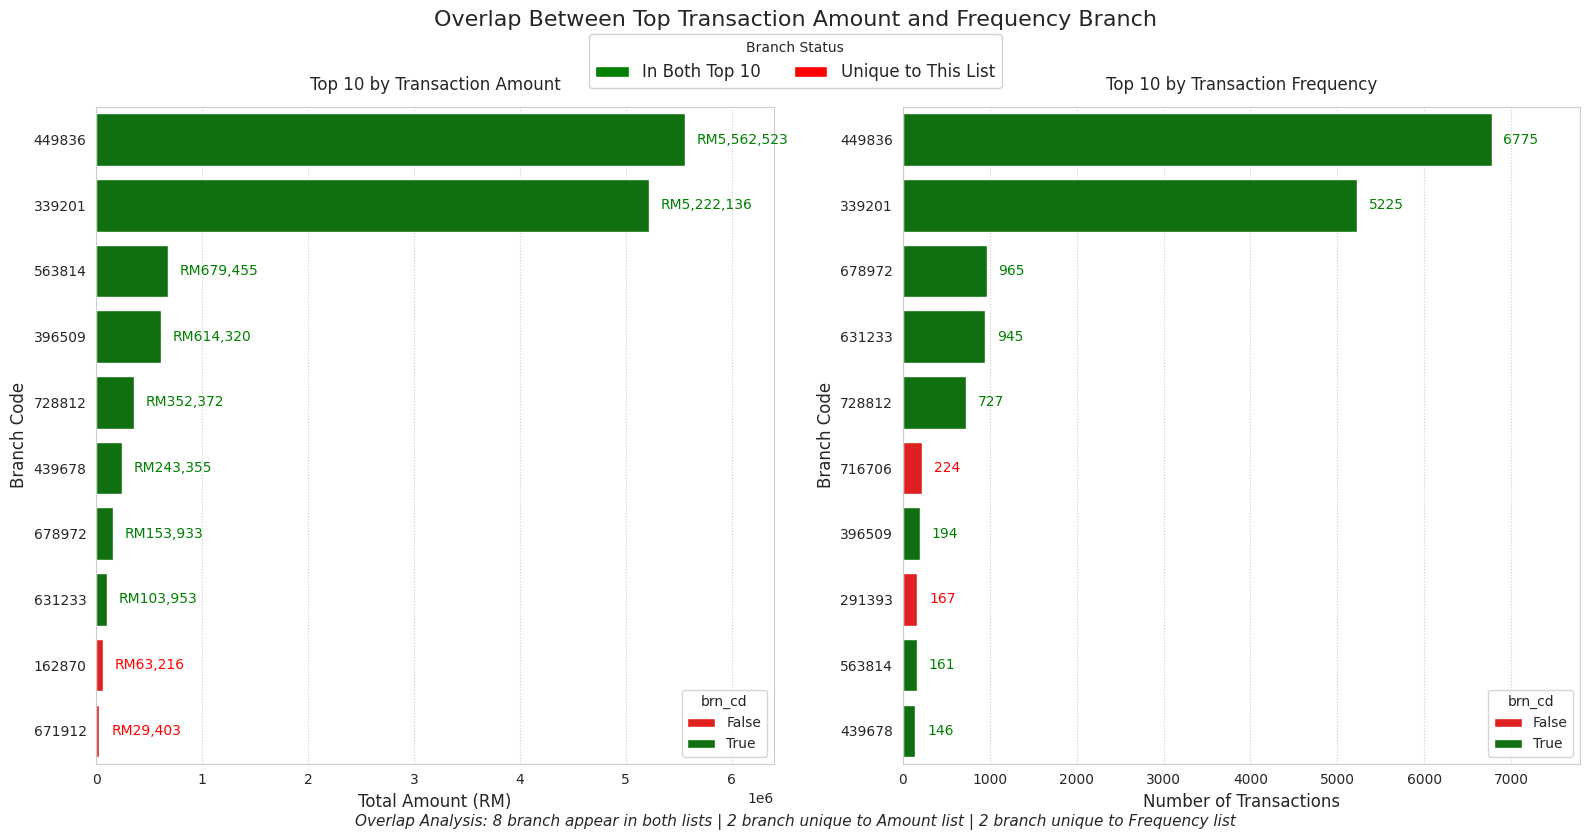


Branch appearing in both top 10 lists:


,brn_cd,count,total_amount
13,449836,6775,5562523.33
7,339201,5225,5222135.97
15,563814,161,679455.45
11,396509,194,614320.00
23,728812,727,352371.65
12,439678,146,243355.03
20,678972,965,153933.32
16,631233,945,103952.52


In [353]:
# @title
# Get the top 10 branch for amount and frequency
top_amount = trn_brn.sort_values('total_amount', ascending=False).head(10)
top_freq = trn_brn.sort_values('count', ascending=False).head(10)

# Find the overlapping branch
common_branch = set(top_amount['brn_cd']).intersection(set(top_freq['brn_cd']))
is_common_amount = top_amount['brn_cd'].isin(common_branch)
is_common_freq = top_freq['brn_cd'].isin(common_branch)

# Create the visualization
plt.figure(figsize=(16, 8))
plt.suptitle('Overlap Between Top Transaction Amount and Frequency Branch', fontsize=16, y=1.02)

# --------------------------------------------------
# Plot 1: Top Amount Customers with Overlap Highlight
# --------------------------------------------------
plt.subplot(1, 2, 1)
bar1 = sns.barplot(
    data=top_amount,
    x='total_amount',
    y='brn_cd',
    hue=is_common_amount,
    palette={True: 'green', False: 'red'},
    orient='h',
    dodge=False,
    edgecolor='white',
    linewidth=1
)

# Add value labels
for i, (_, row) in enumerate(top_amount.iterrows()):
    color = 'green' if row['brn_cd'] in common_branch else 'red'
    bar1.text(
        row['total_amount'] + max(top_amount['total_amount'])*0.02,
        i,
        f"RM{row['total_amount']:,.0f}",
        va='center',
        fontsize=10,
        color=color
    )

plt.title('Top 10 by Transaction Amount', fontsize=12, pad=12)
plt.xlabel('Total Amount (RM)', fontsize=12)
plt.ylabel('Branch Code', fontsize=12)
plt.xlim(0, max(top_amount['total_amount'])*1.15)

# --------------------------------------------------
# Plot 2: Top Frequency Branch with Overlap Highlight
# --------------------------------------------------
plt.subplot(1, 2, 2)
bar2 = sns.barplot(
    data=top_freq,
    x='count',
    y='brn_cd',
    hue=is_common_freq,
    palette={True: 'green', False: 'red'},
    orient='h',
    dodge=False,
    edgecolor='white',
    linewidth=1
)

# Add value labels
for i, (_, row) in enumerate(top_freq.iterrows()):
    color = 'green' if row['brn_cd'] in common_branch else 'red'
    bar2.text(
        row['count'] + max(top_freq['count'])*0.02,
        i,
        f"{row['count']}",
        va='center',
        fontsize=10,
        color=color
    )

plt.title('Top 10 by Transaction Frequency', fontsize=12, pad=12)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Branch Code', fontsize=12)
plt.xlim(0, max(top_freq['count'])*1.15)

# --------------------------------------------------
# Custom Legend
# --------------------------------------------------
legend_elements = [
    plt.Rectangle((0,0),1,1, fc='green', edgecolor='white', label='In Both Top 10'),
    plt.Rectangle((0,0),1,1, fc='red', edgecolor='white', label='Unique to This List')
]

plt.figlegend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=2,
    frameon=True,
    framealpha=0.9,
    fontsize=12,
    title='Branch Status',
    title_fontsize=10
)

# --------------------------------------------------
# Summary Statistics
# --------------------------------------------------
overlap_count = len(common_branch)
unique_amount = len(top_amount) - overlap_count
unique_freq = len(top_freq) - overlap_count

plt.figtext(
    0.5, 0,
    f"Overlap Analysis: {overlap_count} branch appear in both lists | "
    f"{unique_amount} branch unique to Amount list | "
    f"{unique_freq} branch unique to Frequency list",
    ha='center',
    fontsize=11,
    style='italic'
)

plt.tight_layout()
plt.show()

# Print the overlapping branch
if len(common_branch) > 0:
    print("\nBranch appearing in both top 10 lists:")
    overlap_df = top_amount[top_amount['brn_cd'].isin(common_branch)]
    display(overlap_df[['brn_cd', 'count', 'total_amount']])
else:
    print("\nNo branch appear in both top 10 lists")